════════════════════════════════════════════════════════════
1A. ADJACENCY MATRIX — Road Network (0 = no direct road)
════════════════════════════════════════════════════════════
               Delhi    Jaipur      Agra   Lucknow    Kanpur  Varanasi     Patna
────────────────────────────────────────────────────────────────────────────────
     Delhi         0       282       233       571         0         0         0
    Jaipur       282         0       240         0         0         0         0
      Agra       233         0         0       363       298         0         0
   Lucknow         0         0         0         0        80       286         0
    Kanpur         0         0         0         0         0       330         0
  Varanasi         0         0         0         0         0         0       233
     Patna         0         0         0         0         0         0         0

Has edge Delhi→Agra?    True
Has edge Patna→Delhi?   False
Neighbours of Agra:     [('Delhi

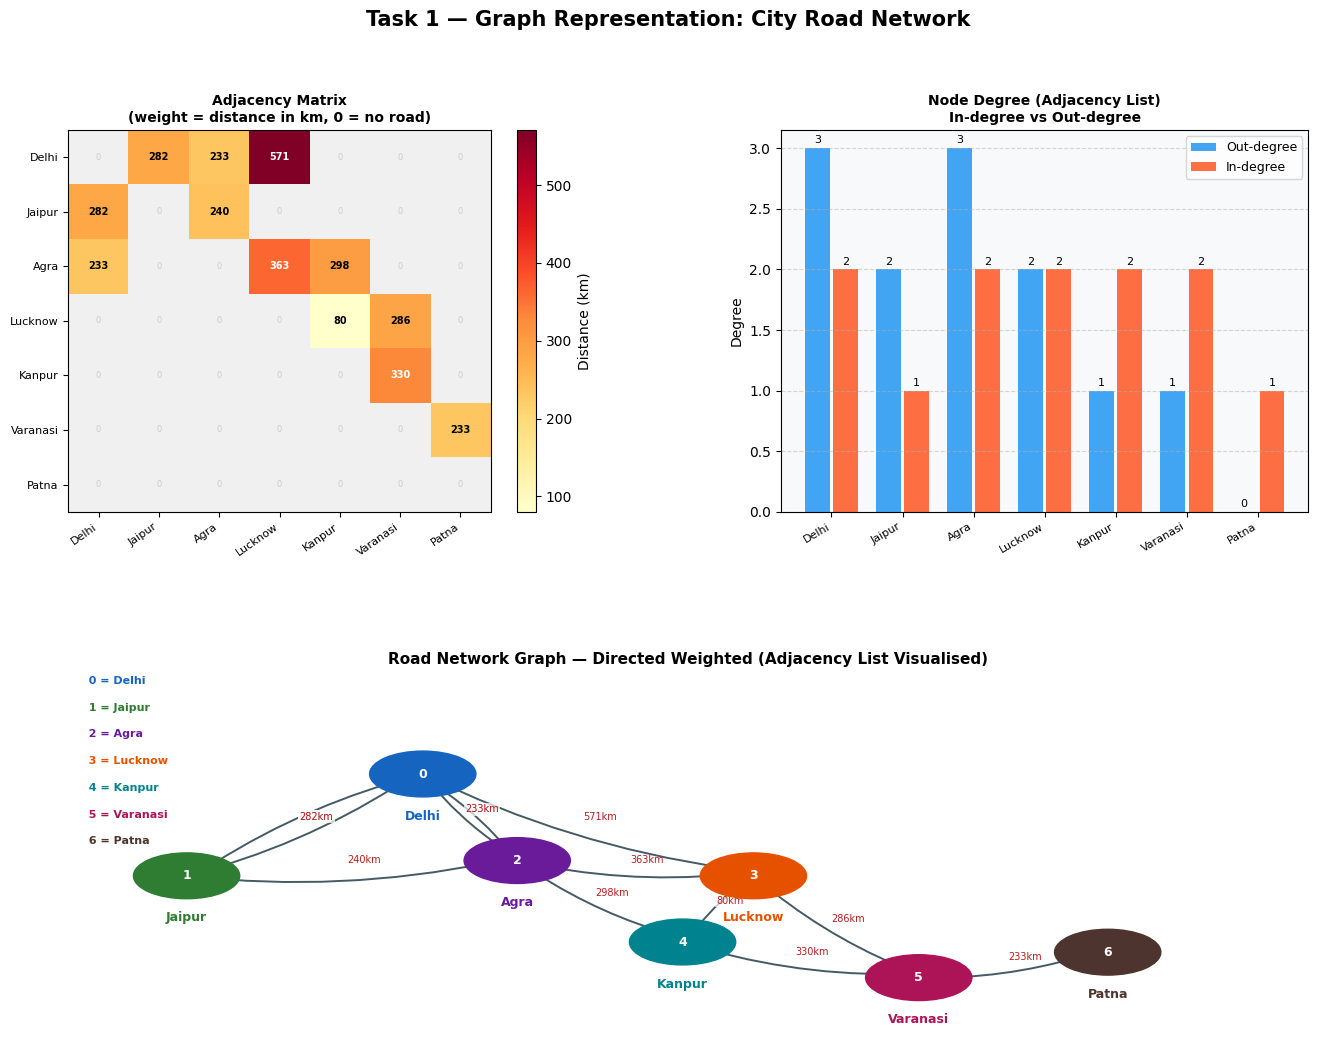

In [19]:
# ============================================================
# TASK 1: GRAPH REPRESENTATION
# Covers:
#   1A. Adjacency Matrix representation
#   1B. Adjacency List representation
#   1C. Visual comparison of both representations
#   1D. Weighted directed graph (road network context)
#
# Real-world context: Road network between cities where nodes
# are cities and edges are roads with distances (weights).
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

# ──────────────────────────────────────────────────────────────
# GRAPH DEFINITION
# We model a road network of 7 Indian cities.
# Directed weighted edges represent one-way road distances (km).
# ──────────────────────────────────────────────────────────────
CITIES = ['Delhi', 'Jaipur', 'Agra', 'Lucknow', 'Kanpur', 'Varanasi', 'Patna']
N = len(CITIES)
city_idx = {city: i for i, city in enumerate(CITIES)}

# Edges: (from, to, weight/distance)
EDGES = [
    ('Delhi',    'Jaipur',   282),
    ('Delhi',    'Agra',     233),
    ('Jaipur',   'Agra',     240),
    ('Agra',     'Lucknow',  363),
    ('Agra',     'Kanpur',   298),
    ('Lucknow',  'Kanpur',    80),
    ('Lucknow',  'Varanasi', 286),
    ('Kanpur',   'Varanasi', 330),
    ('Varanasi', 'Patna',    233),
    ('Delhi',    'Lucknow',  571),
    ('Jaipur',   'Delhi',    282),   # Bidirectional for some roads
    ('Agra',     'Delhi',    233),
]


# ──────────────────────────────────────────────────────────────
# 1A. ADJACENCY MATRIX
# A 2D matrix M where M[i][j] = weight of edge from i to j,
# 0 if no edge exists.
# Space complexity: O(V²) — not efficient for sparse graphs.
# Time to check edge: O(1) — very fast lookup.
# ──────────────────────────────────────────────────────────────
class AdjacencyMatrix:
    """
    Graph represented as an N×N weight matrix.
    matrix[i][j] = edge weight (0 means no edge).
    """
    def __init__(self, num_vertices, vertex_labels):
        self.V      = num_vertices
        self.labels = vertex_labels
        self.matrix = [[0] * num_vertices for _ in range(num_vertices)]

    def add_edge(self, u, v, weight=1):
        """Add directed edge u → v with given weight."""
        self.matrix[u][v] = weight

    def remove_edge(self, u, v):
        """Remove directed edge u → v."""
        self.matrix[u][v] = 0

    def has_edge(self, u, v):
        """Check if edge u → v exists. O(1)."""
        return self.matrix[u][v] != 0

    def get_neighbours(self, u):
        """Return list of (neighbour, weight) for vertex u. O(V)."""
        return [(v, self.matrix[u][v]) for v in range(self.V) if self.matrix[u][v] != 0]

    def display(self):
        """Pretty-print the adjacency matrix."""
        col_w = 10
        header = " " * col_w + "".join(f"{lbl:>{col_w}}" for lbl in self.labels)
        print(header)
        print("─" * len(header))
        for i, row in enumerate(self.matrix):
            row_str = f"{self.labels[i]:>{col_w}}" + "".join(f"{val:>{col_w}}" for val in row)
            print(row_str)


# Build adjacency matrix
adj_matrix = AdjacencyMatrix(N, CITIES)
for src, dst, wt in EDGES:
    adj_matrix.add_edge(city_idx[src], city_idx[dst], wt)

print("═" * 60)
print("1A. ADJACENCY MATRIX — Road Network (0 = no direct road)")
print("═" * 60)
adj_matrix.display()
print(f"\nHas edge Delhi→Agra?    {adj_matrix.has_edge(city_idx['Delhi'], city_idx['Agra'])}")
print(f"Has edge Patna→Delhi?   {adj_matrix.has_edge(city_idx['Patna'], city_idx['Delhi'])}")
print(f"Neighbours of Agra:     {[(CITIES[v], w) for v,w in adj_matrix.get_neighbours(city_idx['Agra'])]}")
print(f"\nSpace used: {N}×{N} = {N*N} cells  (includes {N*N - len(EDGES)} empty cells)")


# ──────────────────────────────────────────────────────────────
# 1B. ADJACENCY LIST
# A dictionary where each key maps to a list of (neighbour, weight).
# Space complexity: O(V + E) — efficient for sparse graphs.
# Time to check edge: O(degree(u)) — slower than matrix.
# ──────────────────────────────────────────────────────────────
class AdjacencyList:
    """
    Graph represented as a dictionary of neighbour lists.
    adj[u] = [(v1, w1), (v2, w2), ...] for edges u→v1, u→v2, ...
    """
    def __init__(self, vertex_labels):
        self.labels = vertex_labels
        self.adj    = defaultdict(list)       # {vertex: [(neighbour, weight), ...]}
        self.V      = len(vertex_labels)
        self.E      = 0

    def add_edge(self, u, v, weight=1):
        """Add directed edge u → v with given weight."""
        self.adj[u].append((v, weight))
        self.E += 1

    def remove_edge(self, u, v):
        """Remove directed edge u → v."""
        self.adj[u] = [(nb, w) for nb, w in self.adj[u] if nb != v]

    def has_edge(self, u, v):
        """Check if edge u → v exists. O(degree(u))."""
        return any(nb == v for nb, _ in self.adj[u])

    def get_neighbours(self, u):
        """Return list of (neighbour, weight) for vertex u. O(1) access."""
        return self.adj[u]

    def display(self):
        """Pretty-print the adjacency list."""
        for i, label in enumerate(self.labels):
            neighbours = self.adj[i]
            nb_str = " → ".join(f"{self.labels[v]}({w}km)" for v, w in neighbours) if neighbours else "∅"
            print(f"  {label:<12} :  {nb_str}")


# Build adjacency list
adj_list = AdjacencyList(CITIES)
for src, dst, wt in EDGES:
    adj_list.add_edge(city_idx[src], city_idx[dst], wt)

print("\n" + "═" * 60)
print("1B. ADJACENCY LIST — Road Network (format: City(distance_km))")
print("═" * 60)
adj_list.display()
print(f"\nTotal vertices: {adj_list.V}  |  Total edges: {adj_list.E}")
print(f"Space used: {adj_list.V + adj_list.E} cells  (vs {N*N} for matrix)")


# ──────────────────────────────────────────────────────────────
# 1C. COMPARISON TABLE
# ──────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("1C. REPRESENTATION COMPARISON")
print("═" * 60)
print(f"{'Property':<30} {'Adj Matrix':<20} {'Adj List'}")
print("─" * 70)
comparisons = [
    ("Space complexity",       "O(V²)",        "O(V + E)"),
    ("Add edge",               "O(1)",          "O(1)"),
    ("Remove edge",            "O(1)",          "O(degree)"),
    ("Check edge existence",   "O(1)",          "O(degree)"),
    ("Find all neighbours",    "O(V)",          "O(degree)"),
    ("Best for",               "Dense graphs",  "Sparse graphs"),
    (f"This graph ({N}V,{len(EDGES)}E):", f"{N*N} cells", f"{N+len(EDGES)} cells"),
]
for prop, mat, lst in comparisons:
    print(f"  {prop:<28} {mat:<20} {lst}")


# ──────────────────────────────────────────────────────────────
# 1D. PLOTTING
# ──────────────────────────────────────────────────────────────
# City positions (approximate geographic layout)
POSITIONS = {
    'Delhi':    (0.30, 0.85),
    'Jaipur':   (0.10, 0.65),
    'Agra':     (0.38, 0.68),
    'Lucknow':  (0.58, 0.65),
    'Kanpur':   (0.52, 0.52),
    'Varanasi': (0.72, 0.45),
    'Patna':    (0.88, 0.50),
}

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Task 1 — Graph Representation: City Road Network",
             fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── Plot A: Adjacency Matrix Heatmap ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
mat_arr = np.array(adj_matrix.matrix, dtype=float)
mat_arr_display = np.where(mat_arr == 0, np.nan, mat_arr)
im = ax1.imshow(mat_arr_display, cmap='YlOrRd', aspect='auto')
ax1.set_xticks(range(N)); ax1.set_yticks(range(N))
ax1.set_xticklabels(CITIES, rotation=35, ha='right', fontsize=8)
ax1.set_yticklabels(CITIES, fontsize=8)
for i in range(N):
    for j in range(N):
        val = adj_matrix.matrix[i][j]
        if val != 0:
            ax1.text(j, i, str(val), ha='center', va='center', fontsize=7,
                     color='white' if val > 300 else 'black', fontweight='bold')
        else:
            ax1.text(j, i, '0', ha='center', va='center', fontsize=6, color='#cccccc')
plt.colorbar(im, ax=ax1, label='Distance (km)')
ax1.set_title("Adjacency Matrix\n(weight = distance in km, 0 = no road)", fontsize=10, fontweight='bold')
ax1.set_facecolor('#f0f0f0')

# ── Plot B: Adjacency List Bar Chart (degree per city) ────────
ax2 = fig.add_subplot(gs[0, 1])
out_degrees = [len(adj_list.get_neighbours(i)) for i in range(N)]
in_degrees  = [sum(1 for src, dst, _ in EDGES if city_idx[dst] == i) for i in range(N)]
x = np.arange(N)
b1 = ax2.bar(x - 0.2, out_degrees, 0.35, label='Out-degree', color='#2196F3', alpha=0.85)
b2 = ax2.bar(x + 0.2, in_degrees,  0.35, label='In-degree',  color='#FF5722', alpha=0.85)
ax2.bar_label(b1, fontsize=8, padding=2)
ax2.bar_label(b2, fontsize=8, padding=2)
ax2.set_xticks(x); ax2.set_xticklabels(CITIES, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel("Degree"); ax2.set_title("Node Degree (Adjacency List)\nIn-degree vs Out-degree",
                                         fontsize=10, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.set_facecolor('#f8f9fa')

# ── Plot C: Graph Visualisation (manual drawing) ─────────────
ax3 = fig.add_subplot(gs[1, :])
ax3.set_xlim(0, 1.05); ax3.set_ylim(0.3, 1.05)
ax3.set_facecolor('#EEF2F7')
ax3.set_title("Road Network Graph — Directed Weighted (Adjacency List Visualised)",
              fontsize=11, fontweight='bold')

# Draw edges with arrows
for src, dst, wt in EDGES:
    x0, y0 = POSITIONS[src]
    x1, y1 = POSITIONS[dst]
    dx, dy = x1 - x0, y1 - y0
    ax3.annotate("", xy=(x1 - 0.02*dx/max(abs(dx),abs(dy),0.01),
                          y1 - 0.02*dy/max(abs(dx),abs(dy),0.01)),
                 xytext=(x0, y0),
                 arrowprops=dict(arrowstyle='->', color='#455A64', lw=1.4,
                                 connectionstyle='arc3,rad=0.08'))
    mx, my = (x0 + x1) / 2 + 0.01, (y0 + y1) / 2 + 0.01
    ax3.text(mx, my, f"{wt}km", fontsize=7, color='#B71C1C', ha='center',
             bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))

# Draw city nodes
city_colors = ['#1565C0','#2E7D32','#6A1B9A','#E65100',
                '#00838F','#AD1457','#4E342E']
for i, (city, (x, y)) in enumerate(POSITIONS.items()):
    circle = plt.Circle((x, y), 0.045, color=city_colors[i], zorder=5)
    ax3.add_patch(circle)
    ax3.text(x, y, str(i), ha='center', va='center', fontsize=9,
             color='white', fontweight='bold', zorder=6)
    ax3.text(x, y - 0.07, city, ha='center', va='top', fontsize=9,
             fontweight='bold', color=city_colors[i])

# Legend for node numbering
for i, city in enumerate(CITIES):
    ax3.text(0.01, 0.99 - i*0.07, f"  {i} = {city}", transform=ax3.transAxes,
             fontsize=8, va='top', color=city_colors[i], fontweight='bold')

ax3.axis('off')

plt.show()

═════════════════════════════════════════════════════════════════
2A. BFS — Social Network (starting from Alice)
═════════════════════════════════════════════════════════════════
Visit Order: Alice → Bob → Charlie → Diana → Eve → Frank → Grace → Henry → Iris → Jack → Karen → Leo

BFS Levels (distance from Alice):
  Level 0: Alice
  Level 1: Bob, Charlie, Diana
  Level 2: Eve, Frank, Grace, Henry, Iris
  Level 3: Jack, Karen, Leo

Friend Suggestions for Alice (level-2 connections):
  → Eve  (via Bob)
  → Frank  (via Bob)
  → Grace  (via Charlie)
  → Henry  (via Charlie)
  → Iris  (via Diana)

═════════════════════════════════════════════════════════════════
2B. DFS — Social Network (starting from Alice)
═════════════════════════════════════════════════════════════════
Visit Order: Alice → Bob → Eve → Jack → Frank → Karen → Grace → Charlie → Henry → Leo → Diana → Iris

Discovery / Finish times:
  Person        Discovery   Finish
  ────────────────────────────────
  Alice                 

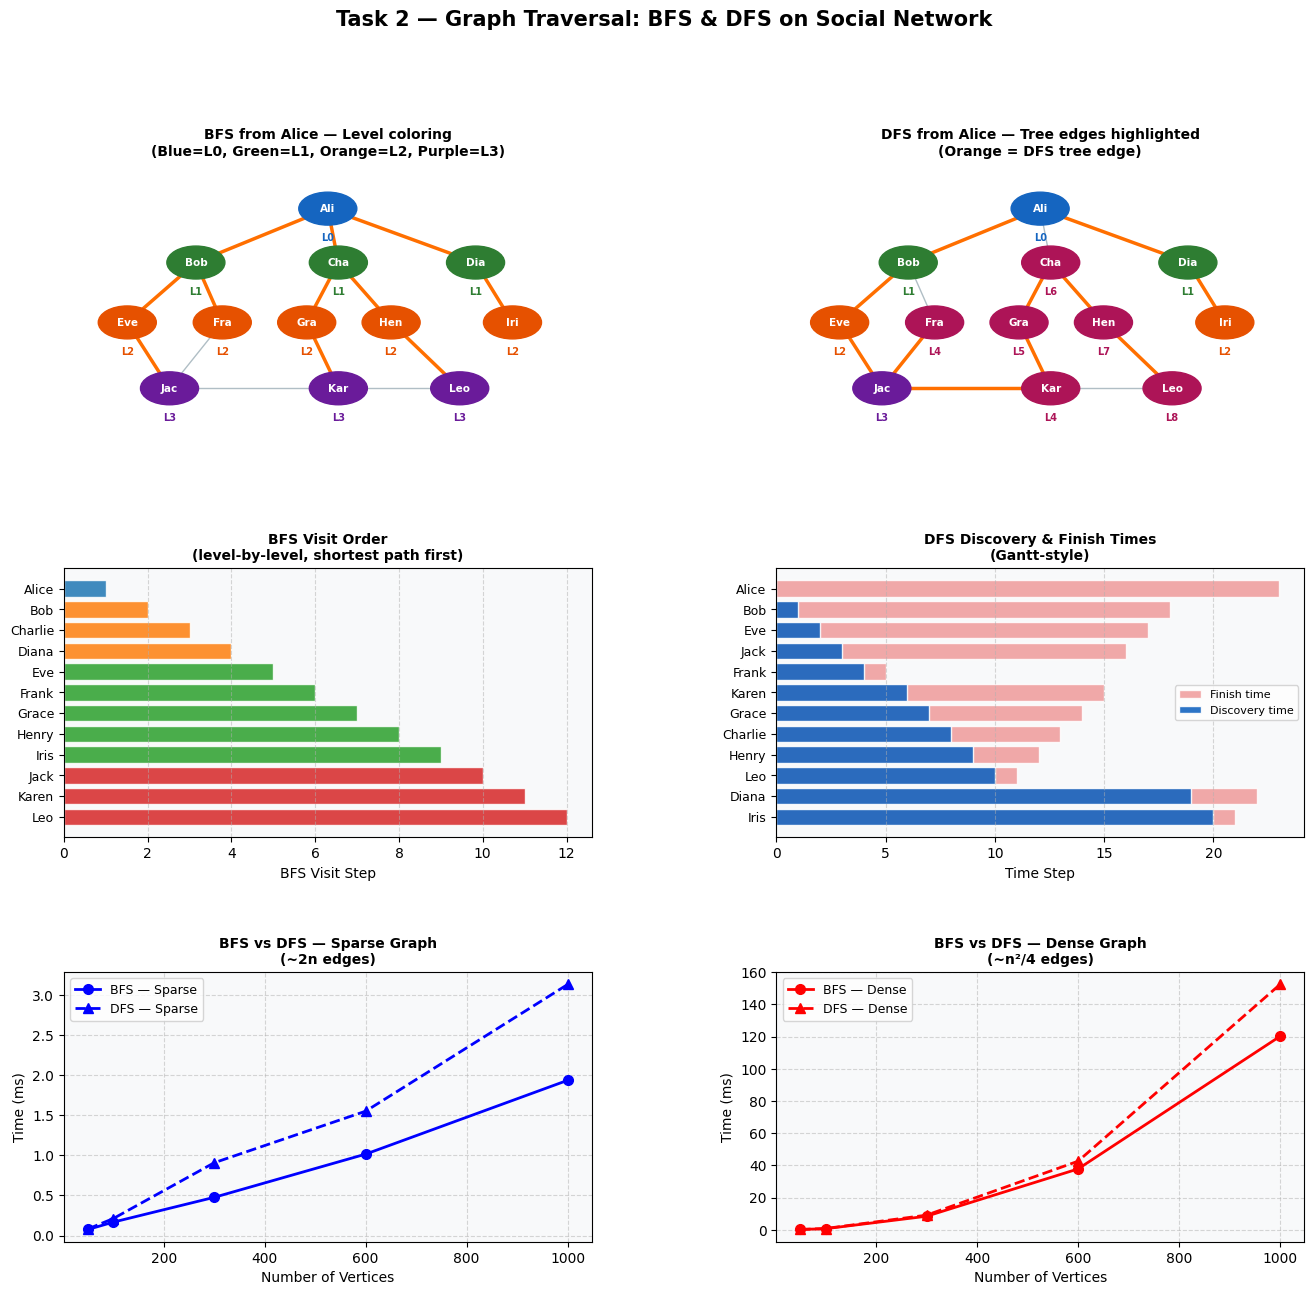

In [20]:
# ============================================================
# TASK 2: GRAPH TRAVERSAL ALGORITHMS
# Covers:
#   2A. Breadth-First Search (BFS)  — O(V + E)
#   2B. Depth-First Search (DFS)    — O(V + E)
#   2C. Real-world context: Social network friend suggestion
#   2D. BFS vs DFS: Layer-by-layer vs path exploration
#   2E. Performance comparison on sparse vs dense graphs
# ============================================================

import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from collections import deque, defaultdict

# ──────────────────────────────────────────────────────────────
# GRAPH SETUP — Social Network (undirected, unweighted)
# Nodes = people, Edges = friendship connections
# ──────────────────────────────────────────────────────────────
PEOPLE = ['Alice','Bob','Charlie','Diana','Eve','Frank','Grace','Henry',
          'Iris','Jack','Karen','Leo']
N_P = len(PEOPLE)
person_idx = {p: i for i, p in enumerate(PEOPLE)}

# Friendship edges (undirected)
FRIENDSHIPS = [
    ('Alice','Bob'),('Alice','Charlie'),('Alice','Diana'),
    ('Bob','Eve'),('Bob','Frank'),
    ('Charlie','Grace'),('Charlie','Henry'),
    ('Diana','Iris'),
    ('Eve','Jack'),('Frank','Jack'),
    ('Grace','Karen'),('Henry','Leo'),
    ('Jack','Karen'),('Karen','Leo'),
]


def build_undirected_adj(people, edges):
    """Build adjacency list for an undirected graph."""
    adj = defaultdict(list)
    for u, v in edges:
        adj[person_idx[u]].append(person_idx[v])
        adj[person_idx[v]].append(person_idx[u])
    return adj

social_adj = build_undirected_adj(PEOPLE, FRIENDSHIPS)


# ──────────────────────────────────────────────────────────────
# 2A. BREADTH-FIRST SEARCH (BFS)
# Explores nodes LEVEL BY LEVEL using a queue (FIFO).
# Use cases: shortest path (unweighted), friend suggestions,
#            web crawling, level-order traversal.
# Time: O(V + E)   Space: O(V)
# ──────────────────────────────────────────────────────────────
def bfs(adj, start, num_vertices):
    """
    BFS from 'start' node.
    Returns:
      - visit_order : list of nodes in BFS visit order
      - levels      : dict {node: BFS level (distance from start)}
      - parent      : dict {node: parent in BFS tree}
      - bfs_tree    : list of tree edges
    """
    visited    = [False] * num_vertices
    levels     = {start: 0}
    parent     = {start: None}
    visit_order= []
    bfs_tree   = []
    queue      = deque([start])
    visited[start] = True

    while queue:
        node = queue.popleft()           # FIFO — explore shallowest first
        visit_order.append(node)

        for neighbour in sorted(adj[node]):   # sorted for determinism
            if not visited[neighbour]:
                visited[neighbour]  = True
                levels[neighbour]   = levels[node] + 1
                parent[neighbour]   = node
                bfs_tree.append((node, neighbour))
                queue.append(neighbour)

    return visit_order, levels, parent, bfs_tree


# ── Friend Suggestion using BFS ───────────────────────────────
def friend_suggestion(adj, person_id, people_names, max_level=2):
    """
    Suggest friends-of-friends using BFS up to max_level hops.
    Direct friends (level 1) are excluded; levels 2+ are suggestions.
    """
    _, levels, _, _ = bfs(adj, person_id, len(people_names))
    direct_friends  = {nb for nb in adj[person_id]}
    suggestions     = {node: lvl for node, lvl in levels.items()
                       if node != person_id
                       and node not in direct_friends
                       and 1 < lvl <= max_level}
    return suggestions


start_bfs = person_idx['Alice']
bfs_order, bfs_levels, bfs_parent, bfs_tree = bfs(social_adj, start_bfs, N_P)

print("═" * 65)
print("2A. BFS — Social Network (starting from Alice)")
print("═" * 65)
print(f"Visit Order: {' → '.join(PEOPLE[i] for i in bfs_order)}")
print(f"\nBFS Levels (distance from Alice):")
for level in range(max(bfs_levels.values()) + 1):
    nodes_at_level = [PEOPLE[n] for n, l in bfs_levels.items() if l == level]
    print(f"  Level {level}: {', '.join(nodes_at_level)}")

suggestions = friend_suggestion(social_adj, start_bfs, PEOPLE, max_level=2)
print(f"\nFriend Suggestions for Alice (level-2 connections):")
for node, lvl in sorted(suggestions.items(), key=lambda x: x[1]):
    print(f"  → {PEOPLE[node]}  (via {PEOPLE[bfs_parent[node]]})")


# ──────────────────────────────────────────────────────────────
# 2B. DEPTH-FIRST SEARCH (DFS)
# Explores nodes by going as DEEP as possible before backtracking.
# Use cases: cycle detection, topological sort, maze solving,
#            connected components, path finding.
# Time: O(V + E)   Space: O(V) recursion stack
# ──────────────────────────────────────────────────────────────
def dfs(adj, start, num_vertices):
    """
    Iterative DFS from 'start' node (using explicit stack to avoid recursion limit).
    Returns:
      - visit_order : list of nodes in DFS visit order
      - dfs_tree    : list of tree edges
      - discovery   : dict {node: discovery time}
      - finish      : dict {node: finish time}
    """
    visited    = [False] * num_vertices
    visit_order= []
    dfs_tree   = []
    discovery  = {}
    finish     = {}
    parent     = {start: None}
    timer      = [0]

    def dfs_recursive(node):
        visited[node] = True
        discovery[node] = timer[0]; timer[0] += 1
        visit_order.append(node)
        for neighbour in sorted(adj[node]):
            if not visited[neighbour]:
                parent[neighbour] = node
                dfs_tree.append((node, neighbour))
                dfs_recursive(neighbour)
        finish[node] = timer[0]; timer[0] += 1

    dfs_recursive(start)
    # Handle disconnected components
    for node in range(num_vertices):
        if not visited[node]:
            dfs_recursive(node)

    return visit_order, dfs_tree, discovery, finish, parent


start_dfs = person_idx['Alice']
dfs_order, dfs_tree_edges, disc, fin, dfs_parent = dfs(social_adj, start_dfs, N_P)

print("\n" + "═" * 65)
print("2B. DFS — Social Network (starting from Alice)")
print("═" * 65)
print(f"Visit Order: {' → '.join(PEOPLE[i] for i in dfs_order)}")
print(f"\nDiscovery / Finish times:")
print(f"  {'Person':<12} {'Discovery':>10} {'Finish':>8}")
print("  " + "─" * 32)
for node in dfs_order:
    print(f"  {PEOPLE[node]:<12} {disc[node]:>10} {fin[node]:>8}")

print(f"\nDFS Tree Edges:")
for u, v in dfs_tree_edges:
    print(f"  {PEOPLE[u]} → {PEOPLE[v]}")


# ──────────────────────────────────────────────────────────────
# 2C. PERFORMANCE COMPARISON ON SPARSE vs DENSE GRAPHS
# ──────────────────────────────────────────────────────────────
def random_graph_adj(num_v, num_e, directed=False):
    """Generate a random graph adjacency list with given V and E."""
    adj = defaultdict(list)
    edges_added = set()
    while len(edges_added) < num_e:
        u = random.randint(0, num_v - 1)
        v = random.randint(0, num_v - 1)
        if u != v and (u, v) not in edges_added:
            adj[u].append(v)
            if not directed:
                adj[v].append(u)
            edges_added.add((u, v))
    return adj

sizes     = [50, 100, 300, 600, 1000]
TRIALS    = 5
bfs_sparse, dfs_sparse = [], []
bfs_dense,  dfs_dense  = [], []

print("\nPerformance Measurement (BFS vs DFS):")
for n in sizes:
    E_sparse = n * 2        # Sparse: ~2n edges
    E_dense  = n * (n-1)//4 # Dense:  ~n²/4 edges

    # Sparse graph
    sparse_adj = random_graph_adj(n, min(E_sparse, n*(n-1)//2))
    t_bfs, t_dfs = [], []
    for _ in range(TRIALS):
        t0 = time.perf_counter(); bfs(sparse_adj, 0, n); t_bfs.append(time.perf_counter()-t0)
        t0 = time.perf_counter(); dfs(sparse_adj, 0, n); t_dfs.append(time.perf_counter()-t0)
    bfs_sparse.append(np.mean(t_bfs)*1000)
    dfs_sparse.append(np.mean(t_dfs)*1000)

    # Dense graph
    dense_adj = random_graph_adj(n, min(E_dense, n*(n-1)//2))
    t_bfs, t_dfs = [], []
    for _ in range(TRIALS):
        t0 = time.perf_counter(); bfs(dense_adj, 0, n); t_bfs.append(time.perf_counter()-t0)
        t0 = time.perf_counter(); dfs(dense_adj, 0, n); t_dfs.append(time.perf_counter()-t0)
    bfs_dense.append(np.mean(t_bfs)*1000)
    dfs_dense.append(np.mean(t_dfs)*1000)

    print(f"  n={n:>5} | Sparse → BFS:{bfs_sparse[-1]:.3f}ms  DFS:{dfs_sparse[-1]:.3f}ms "
          f"| Dense → BFS:{bfs_dense[-1]:.3f}ms  DFS:{dfs_dense[-1]:.3f}ms")


# ──────────────────────────────────────────────────────────────
# PLOTTING
# ──────────────────────────────────────────────────────────────
PERSON_POS = {
    'Alice':   (0.50, 0.90), 'Bob':     (0.25, 0.72), 'Charlie': (0.52, 0.72),
    'Diana':   (0.78, 0.72), 'Eve':     (0.12, 0.52), 'Frank':   (0.30, 0.52),
    'Grace':   (0.46, 0.52), 'Henry':   (0.62, 0.52), 'Iris':    (0.85, 0.52),
    'Jack':    (0.20, 0.30), 'Karen':   (0.52, 0.30), 'Leo':     (0.75, 0.30),
}

def draw_social_graph(ax, highlight_edges=None, highlight_nodes=None,
                      node_labels=None, title=""):
    """Draw the social network graph on the given axis."""
    ax.set_xlim(0, 1); ax.set_ylim(0.15, 1.05)
    ax.set_facecolor('#EEF6FF'); ax.axis('off')
    ax.set_title(title, fontsize=10, fontweight='bold')

    level_colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A','#AD1457']

    # Draw all edges
    for u, v in FRIENDSHIPS:
        x0,y0 = PERSON_POS[u]; x1,y1 = PERSON_POS[v]
        edge_color = '#B0BEC5'
        lw = 1.0
        if highlight_edges and ((person_idx[u],person_idx[v]) in highlight_edges or
                                 (person_idx[v],person_idx[u]) in highlight_edges):
            edge_color = '#FF6F00'; lw = 2.5
        ax.plot([x0,x1],[y0,y1], color=edge_color, lw=lw, zorder=1)

    # Draw nodes
    for name, (x, y) in PERSON_POS.items():
        idx = person_idx[name]
        lvl = node_labels.get(idx, -1) if node_labels else -1
        color = level_colors[min(lvl, len(level_colors)-1)] if lvl >= 0 else '#90A4AE'
        circle = plt.Circle((x, y), 0.055, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, name[:3], ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold', zorder=4)
        if node_labels and idx in node_labels:
            ax.text(x, y - 0.08, f"L{node_labels[idx]}", ha='center', va='top',
                    fontsize=7, color=level_colors[min(lvl,4)], fontweight='bold')

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Task 2 — Graph Traversal: BFS & DFS on Social Network",
             fontsize=15, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

# ── Plot A: BFS levels visualisation ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
draw_social_graph(ax1, highlight_edges=set(bfs_tree),
                  node_labels=bfs_levels,
                  title=f"BFS from Alice — Level coloring\n(Blue=L0, Green=L1, Orange=L2, Purple=L3)")

# ── Plot B: DFS tree edges visualisation ─────────────────────
ax2 = fig.add_subplot(gs[0, 1])
dfs_level_map = {}
def compute_dfs_levels(parent_map, start):
    levels = {start: 0}
    for node, par in parent_map.items():
        if par is not None and node not in levels:
            levels[node] = levels.get(par, 0) + 1
    return levels
dfs_lvl = compute_dfs_levels(dfs_parent, start_dfs)
draw_social_graph(ax2, highlight_edges=set(dfs_tree_edges),
                  node_labels=dfs_lvl,
                  title="DFS from Alice — Tree edges highlighted\n(Orange = DFS tree edge)")

# ── Plot C: BFS visit order bar ──────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
bfs_names = [PEOPLE[i] for i in bfs_order]
ax3.barh(range(len(bfs_order)), range(1, len(bfs_order)+1),
         color=[f'C{bfs_levels.get(i, 0)}' for i in bfs_order], alpha=0.85, edgecolor='white')
ax3.set_yticks(range(len(bfs_order)))
ax3.set_yticklabels(bfs_names, fontsize=9)
ax3.set_xlabel("BFS Visit Step")
ax3.set_title("BFS Visit Order\n(level-by-level, shortest path first)", fontsize=10, fontweight='bold')
ax3.grid(axis='x', linestyle='--', alpha=0.5); ax3.set_facecolor('#f8f9fa')
ax3.invert_yaxis()

# ── Plot D: DFS discovery/finish time ────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
sorted_nodes = sorted(disc.keys(), key=lambda x: disc[x])
names_sorted = [PEOPLE[n] for n in sorted_nodes]
disc_vals    = [disc[n] for n in sorted_nodes]
fin_vals     = [fin[n]  for n in sorted_nodes]
y = range(len(sorted_nodes))
ax4.barh(y, fin_vals,  color='#EF9A9A', alpha=0.85, label='Finish time',   edgecolor='white')
ax4.barh(y, disc_vals, color='#1565C0', alpha=0.9,  label='Discovery time', edgecolor='white')
ax4.set_yticks(y); ax4.set_yticklabels(names_sorted, fontsize=9)
ax4.set_xlabel("Time Step")
ax4.set_title("DFS Discovery & Finish Times\n(Gantt-style)", fontsize=10, fontweight='bold')
ax4.legend(fontsize=8); ax4.grid(axis='x', linestyle='--', alpha=0.5)
ax4.set_facecolor('#f8f9fa'); ax4.invert_yaxis()

# ── Plot E: BFS vs DFS sparse timing ─────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(sizes, bfs_sparse, 'bo-', lw=2, ms=7, label='BFS — Sparse')
ax5.plot(sizes, dfs_sparse, 'b^--', lw=2, ms=7, label='DFS — Sparse')
ax5.set_xlabel("Number of Vertices"); ax5.set_ylabel("Time (ms)")
ax5.set_title("BFS vs DFS — Sparse Graph\n(~2n edges)", fontsize=10, fontweight='bold')
ax5.legend(fontsize=9); ax5.grid(True, linestyle='--', alpha=0.5)
ax5.set_facecolor('#f8f9fa')

# ── Plot F: BFS vs DFS dense timing ──────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(sizes, bfs_dense, 'ro-', lw=2, ms=7, label='BFS — Dense')
ax6.plot(sizes, dfs_dense, 'r^--', lw=2, ms=7, label='DFS — Dense')
ax6.set_xlabel("Number of Vertices"); ax6.set_ylabel("Time (ms)")
ax6.set_title("BFS vs DFS — Dense Graph\n(~n²/4 edges)", fontsize=10, fontweight='bold')
ax6.legend(fontsize=9); ax6.grid(True, linestyle='--', alpha=0.5)
ax6.set_facecolor('#f8f9fa')

plt.show()

═════════════════════════════════════════════════════════════════
3A. KAHN'S ALGORITHM — Project Task Schedule
═════════════════════════════════════════════════════════════════
Is valid DAG (no cycles): True

Topological Order (valid execution sequence):
  Step  1: Requirements          (no prerequisites)
  Step  2: Design                (prerequisites: Requirements)
  Step  3: Database Schema       (prerequisites: Requirements)
  Step  4: Frontend              (prerequisites: Design)
  Step  5: Backend API           (prerequisites: Design, Database Schema)
  Step  6: Unit Testing          (prerequisites: Frontend, Backend API)
  Step  7: Documentation         (prerequisites: Frontend, Backend API)
  Step  8: Code Review           (prerequisites: Unit Testing)
  Step  9: Integration Test      (prerequisites: Unit Testing, Code Review)
  Step 10: Deployment            (prerequisites: Integration Test, Documentation)

═════════════════════════════════════════════════════════════════
3B. 

C:\Users\goyal\AppData\Local\Temp\ipykernel_50808\1516506447.py:296: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(TASKS, rotation=35, ha='right', fontsize=8)


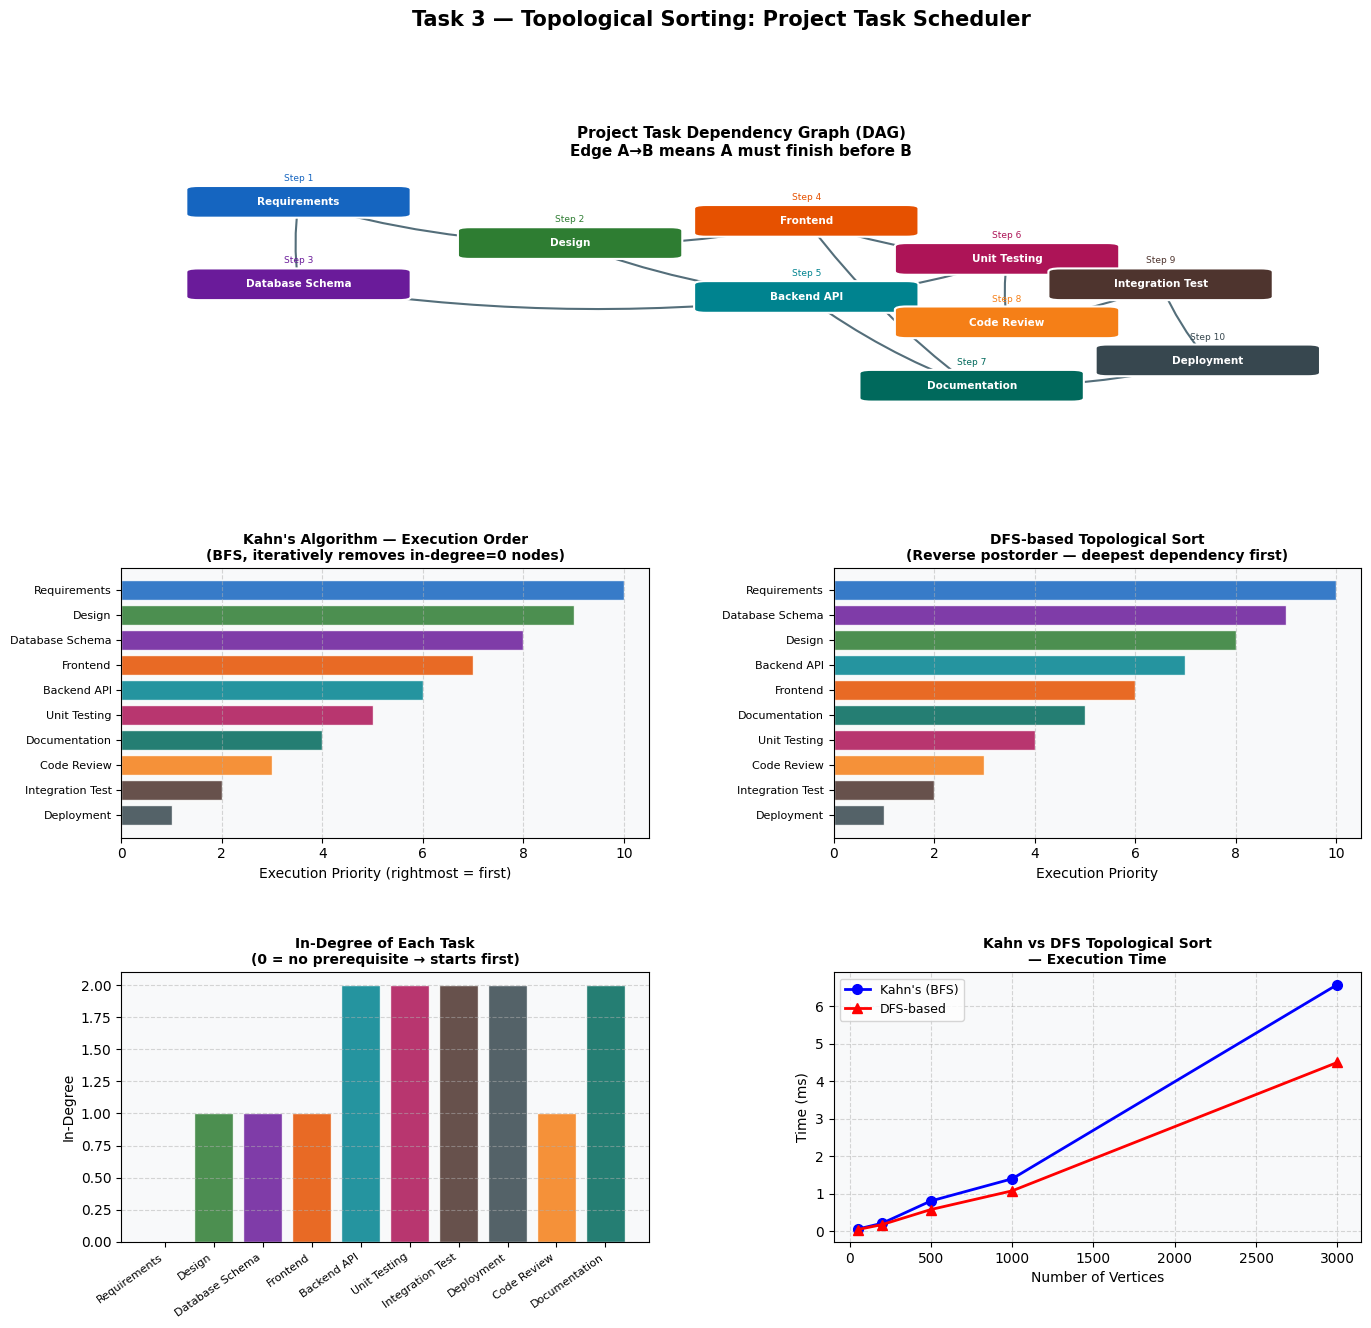

In [21]:
# ============================================================
# TASK 3: TOPOLOGICAL SORTING
# Covers:
#   3A. Kahn's Algorithm (BFS-based)       — O(V + E)
#   3B. DFS-based Topological Sort         — O(V + E)
#   3C. Cycle detection in directed graphs
#   3D. Real-world: Project task scheduling (DAG of dependencies)
# ============================================================

import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from collections import defaultdict, deque

# ──────────────────────────────────────────────────────────────
# DIRECTED ACYCLIC GRAPH (DAG) — Software Project Task Schedule
# Node = Task, Edge A→B means "A must be completed before B"
# ──────────────────────────────────────────────────────────────
TASKS = [
    'Requirements', 'Design', 'Database Schema', 'Frontend',
    'Backend API', 'Unit Testing', 'Integration Test', 'Deployment',
    'Code Review', 'Documentation'
]
N_T = len(TASKS)
task_idx = {t: i for i, t in enumerate(TASKS)}

# Dependencies: (prerequisite, dependent_task)
DEPENDENCIES = [
    ('Requirements',    'Design'),
    ('Requirements',    'Database Schema'),
    ('Design',          'Frontend'),
    ('Design',          'Backend API'),
    ('Database Schema', 'Backend API'),
    ('Frontend',        'Unit Testing'),
    ('Backend API',     'Unit Testing'),
    ('Unit Testing',    'Code Review'),
    ('Unit Testing',    'Integration Test'),
    ('Code Review',     'Integration Test'),
    ('Integration Test','Deployment'),
    ('Backend API',     'Documentation'),
    ('Frontend',        'Documentation'),
    ('Documentation',   'Deployment'),
]

def build_dag(tasks, dependencies):
    """Build directed adjacency list and in-degree map for a DAG."""
    adj      = defaultdict(list)
    in_degree= defaultdict(int)
    for t in tasks:
        in_degree[task_idx[t]] = 0   # Initialise all
    for prereq, task in dependencies:
        u, v = task_idx[prereq], task_idx[task]
        adj[u].append(v)
        in_degree[v] += 1
    return adj, in_degree

dag_adj, in_deg = build_dag(TASKS, DEPENDENCIES)


# ──────────────────────────────────────────────────────────────
# 3A. KAHN'S ALGORITHM (BFS-based Topological Sort)
# Works by repeatedly removing nodes with in-degree = 0.
# If the final result doesn't include all V nodes → cycle exists.
# Time: O(V + E)   Space: O(V)
# ──────────────────────────────────────────────────────────────
def kahn_topological_sort(adj, in_degree, num_vertices):
    """
    Kahn's BFS-based topological sort.
    Returns (topo_order, is_dag) where is_dag = True if no cycle.
    """
    in_deg = dict(in_degree)            # Work on a copy
    queue  = deque(node for node in range(num_vertices) if in_deg[node] == 0)
    order  = []

    while queue:
        node = queue.popleft()          # Take any zero-in-degree node
        order.append(node)
        for neighbour in adj[node]:
            in_deg[neighbour] -= 1      # Remove edge: decrement in-degree
            if in_deg[neighbour] == 0:
                queue.append(neighbour)

    is_dag = len(order) == num_vertices  # Cycle if not all nodes processed
    return order, is_dag


kahn_order, is_dag = kahn_topological_sort(dag_adj, in_deg, N_T)

print("═" * 65)
print("3A. KAHN'S ALGORITHM — Project Task Schedule")
print("═" * 65)
print(f"Is valid DAG (no cycles): {is_dag}")
print(f"\nTopological Order (valid execution sequence):")
for step, node in enumerate(kahn_order, 1):
    prereqs = [TASKS[p] for p in range(N_T) if node in dag_adj[p]]
    print(f"  Step {step:>2}: {TASKS[node]:<20}  "
          f"{'(prerequisites: ' + ', '.join(prereqs) + ')' if prereqs else '(no prerequisites)'}")


# ──────────────────────────────────────────────────────────────
# 3B. DFS-BASED TOPOLOGICAL SORT
# Finishes the deepest dependency first → reversed finish order = topo order.
# Classic approach used in compilers and linkers.
# Time: O(V + E)   Space: O(V)
# ──────────────────────────────────────────────────────────────
def dfs_topological_sort(adj, num_vertices):
    """
    DFS-based topological sort with cycle detection.
    Colors: 0=White(unvisited), 1=Gray(in-stack), 2=Black(done)
    Returns (topo_order, has_cycle)
    """
    color  = [0] * num_vertices          # 0=White, 1=Gray, 2=Black
    stack  = []
    has_cycle = [False]

    def dfs_visit(node):
        if has_cycle[0]: return
        color[node] = 1                  # Mark as in-progress (Gray)
        for neighbour in adj[node]:
            if color[neighbour] == 1:    # Back edge → cycle detected!
                has_cycle[0] = True
                return
            if color[neighbour] == 0:
                dfs_visit(neighbour)
        color[node] = 2                  # Mark as complete (Black)
        stack.append(node)               # Push to stack when done

    for node in range(num_vertices):
        if color[node] == 0:
            dfs_visit(node)

    stack.reverse()                      # Reverse gives topological order
    return stack, has_cycle[0]


dfs_topo, has_cycle = dfs_topological_sort(dag_adj, N_T)

print("\n" + "═" * 65)
print("3B. DFS-BASED TOPOLOGICAL SORT")
print("═" * 65)
print(f"Cycle detected: {has_cycle}")
print(f"\nTopological Order:")
for step, node in enumerate(dfs_topo, 1):
    print(f"  Step {step:>2}: {TASKS[node]}")

# Verify both produce the same valid ordering
print(f"\nKahn Order:  {[TASKS[n] for n in kahn_order]}")
print(f"DFS Order:   {[TASKS[n] for n in dfs_topo]}")
print(f"(Both orderings are valid; multiple correct topological orders may exist)")


# ──────────────────────────────────────────────────────────────
# 3C. CYCLE DETECTION DEMONSTRATION
# Add a fake cyclic edge then run cycle detection
# ──────────────────────────────────────────────────────────────
def add_cycle_demo(adj, in_degree, num_vertices):
    """Add a back-edge to create a cycle and test detection."""
    cyclic_adj = defaultdict(list)
    for k, v in adj.items():
        cyclic_adj[k] = list(v)
    cyclic_adj[task_idx['Deployment']].append(task_idx['Design'])  # CYCLE!
    _, dfs_cycle = dfs_topological_sort(cyclic_adj, num_vertices)
    cyclic_indeg = dict(in_degree)
    cyclic_indeg[task_idx['Design']] += 1
    _, kahn_is_dag = kahn_topological_sort(cyclic_adj, cyclic_indeg, num_vertices)
    return dfs_cycle, not kahn_is_dag

dfs_detected, kahn_detected = add_cycle_demo(dag_adj, in_deg, N_T)
print("\n" + "═" * 65)
print("3C. CYCLE DETECTION (added fake edge: Deployment → Design)")
print("═" * 65)
print(f"  DFS detected cycle:   {dfs_detected}")
print(f"  Kahn detected cycle:  {kahn_detected}")


# ──────────────────────────────────────────────────────────────
# 3D. TIMING: Kahn vs DFS on increasing graph sizes
# ──────────────────────────────────────────────────────────────
import random
def random_dag(num_v, num_e):
    """Generate a random DAG (edges only go from lower to higher index)."""
    adj = defaultdict(list)
    in_deg = defaultdict(int)
    for v in range(num_v): in_deg[v] = 0
    edges = set()
    attempts = 0
    while len(edges) < num_e and attempts < num_e * 10:
        u = random.randint(0, num_v - 2)
        v = random.randint(u + 1, num_v - 1)
        if (u, v) not in edges:
            adj[u].append(v)
            in_deg[v] += 1
            edges.add((u, v))
        attempts += 1
    return adj, in_deg, num_v

sizes_t = [50, 200, 500, 1000, 3000]
TRIALS  = 5
kahn_times, dfs_times_t = [], []
print("\nTiming Topological Sort:")
for n in sizes_t:
    e = n * 3
    adj_t, indeg_t, _ = random_dag(n, e)
    kt, dt = [], []
    for _ in range(TRIALS):
        t0 = time.perf_counter(); kahn_topological_sort(adj_t, dict(indeg_t), n); kt.append(time.perf_counter()-t0)
        t0 = time.perf_counter(); dfs_topological_sort(adj_t, n);                 dt.append(time.perf_counter()-t0)
    kahn_times.append(np.mean(kt)*1000)
    dfs_times_t.append(np.mean(dt)*1000)
    print(f"  n={n:>5} | Kahn: {kahn_times[-1]:.3f}ms  DFS: {dfs_times_t[-1]:.3f}ms")


# ──────────────────────────────────────────────────────────────
# PLOTTING
# ──────────────────────────────────────────────────────────────
TASK_POS = {
    'Requirements':    (0.15, 0.88),
    'Design':          (0.38, 0.75),
    'Database Schema': (0.15, 0.62),
    'Frontend':        (0.58, 0.82),
    'Backend API':     (0.58, 0.58),
    'Unit Testing':    (0.75, 0.70),
    'Code Review':     (0.75, 0.50),
    'Integration Test':(0.88, 0.62),
    'Deployment':      (0.92, 0.38),
    'Documentation':   (0.72, 0.30),
}
TASK_COLORS = ['#1565C0','#2E7D32','#6A1B9A','#E65100','#00838F',
               '#AD1457','#4E342E','#37474F','#F57F17','#00695C']

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Task 3 — Topological Sorting: Project Task Scheduler",
             fontsize=15, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

# ── Plot A: DAG Visualisation ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_xlim(0, 1.05); ax1.set_ylim(0.15, 1.0)
ax1.set_facecolor('#F3F8FF'); ax1.axis('off')
ax1.set_title("Project Task Dependency Graph (DAG)\nEdge A→B means A must finish before B",
              fontsize=11, fontweight='bold')

# Edges
for prereq, task in DEPENDENCIES:
    x0, y0 = TASK_POS[prereq]; x1, y1 = TASK_POS[task]
    ax1.annotate("", xy=(x1, y1), xytext=(x0, y0),
                 arrowprops=dict(arrowstyle='->', color='#546E7A', lw=1.5,
                                 connectionstyle='arc3,rad=0.07'))

# Nodes coloured by topological step
for i, task in enumerate(TASKS):
    step = kahn_order.index(task_idx[task]) + 1
    x, y = TASK_POS[task]
    ax1.add_patch(FancyBboxPatch((x-0.085, y-0.04), 0.17, 0.08,
                                      boxstyle="round,pad=0.01",
                                      fc=TASK_COLORS[i], ec='white', lw=1.5, zorder=3))
    ax1.text(x, y, task, ha='center', va='center',
             fontsize=7.5, color='white', fontweight='bold', zorder=4)
    ax1.text(x, y+0.06, f"Step {step}", ha='center', va='bottom',
             fontsize=6.5, color=TASK_COLORS[i])

# ── Plot B: Kahn's step-by-step ─────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
task_names_ordered = [TASKS[n] for n in kahn_order]
colors_steps = [TASK_COLORS[task_idx[t]] for t in task_names_ordered]
ax2.barh(range(len(kahn_order)), range(len(kahn_order), 0, -1),
         color=colors_steps, alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(kahn_order)))
ax2.set_yticklabels(task_names_ordered, fontsize=8)
ax2.set_xlabel("Execution Priority (rightmost = first)")
ax2.set_title("Kahn's Algorithm — Execution Order\n(BFS, iteratively removes in-degree=0 nodes)",
              fontsize=10, fontweight='bold')
ax2.grid(axis='x', linestyle='--', alpha=0.5); ax2.set_facecolor('#f8f9fa')
ax2.invert_yaxis()

# ── Plot C: DFS topo sort ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
dfs_names_ordered = [TASKS[n] for n in dfs_topo]
dfs_colors_steps  = [TASK_COLORS[task_idx[t]] for t in dfs_names_ordered]
ax3.barh(range(len(dfs_topo)), range(len(dfs_topo), 0, -1),
         color=dfs_colors_steps, alpha=0.85, edgecolor='white')
ax3.set_yticks(range(len(dfs_topo)))
ax3.set_yticklabels(dfs_names_ordered, fontsize=8)
ax3.set_xlabel("Execution Priority")
ax3.set_title("DFS-based Topological Sort\n(Reverse postorder — deepest dependency first)",
              fontsize=10, fontweight='bold')
ax3.grid(axis='x', linestyle='--', alpha=0.5); ax3.set_facecolor('#f8f9fa')
ax3.invert_yaxis()

# ── Plot D: In-degree bar chart ──────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
indegrees = [in_deg[i] for i in range(N_T)]
ax4.bar(TASKS, indegrees, color=TASK_COLORS, alpha=0.85, edgecolor='white')
ax4.set_xticklabels(TASKS, rotation=35, ha='right', fontsize=8)
ax4.set_ylabel("In-Degree"); ax4.set_title("In-Degree of Each Task\n(0 = no prerequisite → starts first)",
                                            fontsize=10, fontweight='bold')
ax4.grid(axis='y', linestyle='--', alpha=0.5); ax4.set_facecolor('#f8f9fa')

# ── Plot E: Timing comparison ────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(sizes_t, kahn_times,   'bo-', lw=2, ms=7, label="Kahn's (BFS)")
ax5.plot(sizes_t, dfs_times_t,  'r^-', lw=2, ms=7, label="DFS-based")
ax5.set_xlabel("Number of Vertices"); ax5.set_ylabel("Time (ms)")
ax5.set_title("Kahn vs DFS Topological Sort\n— Execution Time", fontsize=10, fontweight='bold')
ax5.legend(fontsize=9); ax5.grid(True, linestyle='--', alpha=0.5)
ax5.set_facecolor('#f8f9fa')

plt.show()

═════════════════════════════════════════════════════════════════
4A. DIJKSTRA — Shortest Paths from A-Hospital
═════════════════════════════════════════════════════════════════
Destination        Distance Shortest Path
───────────────────────────────────────────────────────
  B-Junction              3 min    A-Hospital → C-Mall → B-Junction
  C-Mall                  1 min    A-Hospital → C-Mall
  D-Park                  6 min    A-Hospital → C-Mall → E-Station → D-Park
  E-Station               3 min    A-Hospital → C-Mall → E-Station
  F-Airport               8 min    A-Hospital → C-Mall → E-Station → D-Park → F-Airport
  G-University            9 min    A-Hospital → C-Mall → E-Station → D-Park → G-University

═════════════════════════════════════════════════════════════════
4B. BELLMAN-FORD — Shortest Paths (includes negative-weight edges)
    Source: A-Hospital
═════════════════════════════════════════════════════════════════
Negative weight cycle: False

Destination        Distanc

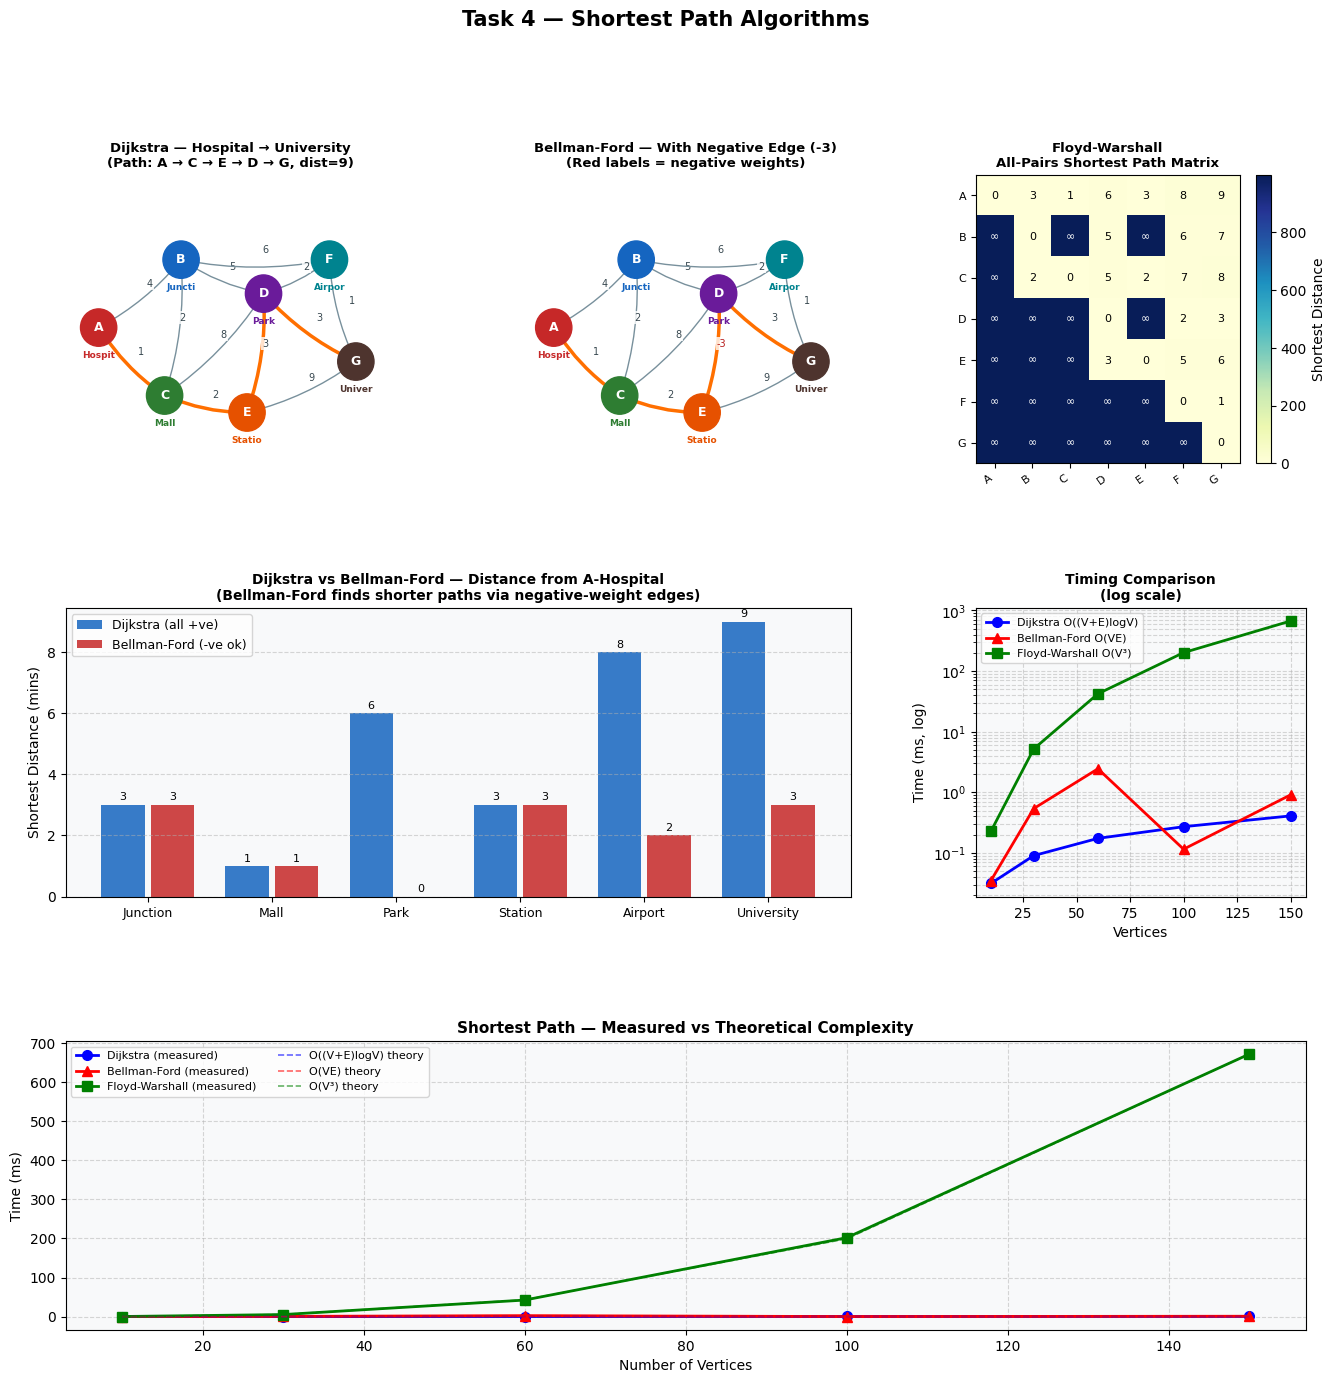

In [22]:
# ============================================================
# TASK 4: SHORTEST PATH ALGORITHMS
# Covers:
#   4A. Dijkstra's Algorithm          — O((V+E) log V)
#   4B. Bellman-Ford Algorithm        — O(V × E)
#   4C. Floyd-Warshall Algorithm      — O(V³)
#   4D. Real-world: Emergency routing + negative-cost detours
#   4E. Time complexity comparison
# ============================================================

import heapq
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

INF = float('inf')

# ──────────────────────────────────────────────────────────────
# GRAPH — City Road Network with weights (travel time in mins)
# Some edges have negative weights (e.g., highway rebates)
# Uses the same cities from Task 1 but with directed weights.
# ──────────────────────────────────────────────────────────────
CITIES_SP = ['A-Hospital', 'B-Junction', 'C-Mall', 'D-Park',
             'E-Station', 'F-Airport', 'G-University']
N_SP = len(CITIES_SP)
sp_idx = {c: i for i, c in enumerate(CITIES_SP)}

# Weighted directed edges (for Dijkstra — all positive)
EDGES_DIJKSTRA = [
    (0, 1, 4),  (0, 2, 1),  (2, 1, 2),  (1, 3, 5),
    (2, 3, 8),  (2, 4, 2),  (4, 3, 3),  (1, 5, 6),
    (3, 5, 2),  (3, 6, 3),  (4, 6, 9),  (5, 6, 1),
]

# Weighted directed edges (for Bellman-Ford — includes negative weights)
EDGES_BELLMAN = [
    (0, 1,  4),  (0, 2,  1),  (2, 1,  2),  (1, 3,  5),
    (2, 3,  8),  (2, 4,  2),  (4, 3, -3),  # negative: shortcut via D-Park!
    (1, 5,  6),  (3, 5,  2),  (3, 6,  3),
    (4, 6,  9),  (5, 6,  1),
]


# ──────────────────────────────────────────────────────────────
# 4A. DIJKSTRA'S ALGORITHM  –  O((V + E) log V)
# Greedy: always extend the shortest known distance.
# REQUIREMENT: All edge weights MUST be non-negative.
# Use case: GPS navigation, network routing.
# ──────────────────────────────────────────────────────────────
def dijkstra(num_v, edges, source):
    """
    Dijkstra's shortest path from 'source' to all other vertices.
    Uses a min-heap (priority queue) for efficiency.
    Returns:
      - dist   : dist[v] = shortest distance from source to v
      - parent : parent[v] = predecessor on shortest path
    """
    # Build adjacency list
    adj = defaultdict(list)
    for u, v, w in edges:
        adj[u].append((v, w))

    dist   = [INF] * num_v
    parent = [-1]  * num_v
    dist[source] = 0

    # Min-heap: (distance, vertex)
    heap = [(0, source)]

    while heap:
        d, u = heapq.heappop(heap)
        if d > dist[u]:                  # Skip stale heap entries
            continue
        for v, w in adj[u]:
            if dist[u] + w < dist[v]:   # Relaxation step
                dist[v]   = dist[u] + w
                parent[v] = u
                heapq.heappush(heap, (dist[v], v))

    return dist, parent


def reconstruct_path(parent, source, target):
    """Trace back parent pointers to reconstruct shortest path."""
    path = []
    node = target
    while node != -1:
        path.append(node)
        node = parent[node]
    path.reverse()
    if path[0] != source:
        return []                        # No path exists
    return path


SOURCE = 0   # Emergency vehicle starts at A-Hospital
dijk_dist, dijk_parent = dijkstra(N_SP, EDGES_DIJKSTRA, SOURCE)

print("═" * 65)
print(f"4A. DIJKSTRA — Shortest Paths from {CITIES_SP[SOURCE]}")
print("═" * 65)
print(f"{'Destination':<16} {'Distance':>10} {'Shortest Path'}")
print("─" * 55)
for v in range(N_SP):
    if v == SOURCE: continue
    path = reconstruct_path(dijk_parent, SOURCE, v)
    path_str = " → ".join(CITIES_SP[p] for p in path) if path else "No path"
    dist_str = str(dijk_dist[v]) if dijk_dist[v] != INF else "∞"
    print(f"  {CITIES_SP[v]:<16} {dist_str:>8} min    {path_str}")


# ──────────────────────────────────────────────────────────────
# 4B. BELLMAN-FORD ALGORITHM  –  O(V × E)
# Relaxes ALL edges V-1 times. Handles negative edge weights.
# Can also detect negative weight CYCLES (impossible in real routing).
# Use case: financial arbitrage detection, networks with rebates.
# ──────────────────────────────────────────────────────────────
def bellman_ford(num_v, edges, source, node_names=None):
    """
    Bellman-Ford shortest path from 'source'.
    Returns:
      - dist        : shortest distances (INF if unreachable)
      - parent      : predecessor on shortest path
      - neg_cycle   : True if negative weight cycle detected
    """
    dist   = [INF] * num_v
    parent = [-1]  * num_v
    dist[source] = 0

    # Relax all edges V-1 times
    for iteration in range(num_v - 1):
        updated = False
        for u, v, w in edges:
            if dist[u] != INF and dist[u] + w < dist[v]:
                dist[v]   = dist[u] + w
                parent[v] = u
                updated = True
        if not updated:                  # Early termination optimisation
            break

    # V-th relaxation pass: check for negative cycles
    neg_cycle = False
    neg_cycle_nodes = []
    for u, v, w in edges:
        if dist[u] != INF and dist[u] + w < dist[v]:
            neg_cycle = True
            if node_names:
                neg_cycle_nodes.append((node_names[u], node_names[v]))
            else:
                neg_cycle_nodes.append((u, v))

    return dist, parent, neg_cycle, neg_cycle_nodes


bf_dist, bf_parent, neg_cycle, neg_nodes = bellman_ford(N_SP, EDGES_BELLMAN, SOURCE, CITIES_SP)

print("\n" + "═" * 65)
print(f"4B. BELLMAN-FORD — Shortest Paths (includes negative-weight edges)")
print(f"    Source: {CITIES_SP[SOURCE]}")
print("═" * 65)
print(f"Negative weight cycle: {neg_cycle}")
print(f"\n{'Destination':<16} {'Distance':>10} {'Shortest Path'}")
print("─" * 55)
for v in range(N_SP):
    if v == SOURCE: continue
    path = reconstruct_path(bf_parent, SOURCE, v)
    path_str = " → ".join(CITIES_SP[p] for p in path) if path else "No path"
    dist_str = str(bf_dist[v]) if bf_dist[v] != INF else "∞"
    print(f"  {CITIES_SP[v]:<16} {dist_str:>8} min    {path_str}")

# Show impact of negative edge
print(f"\nNote: Edge E-Station→D-Park has weight -3 (highway rebate/shortcut).")
print(f"Dijkstra gives D-Park distance = {dijk_dist[sp_idx['D-Park']]} min")
print(f"Bellman-Ford gives D-Park distance = {bf_dist[sp_idx['D-Park']]} min  (shorter due to negative edge)")


# ──────────────────────────────────────────────────────────────
# 4C. FLOYD-WARSHALL ALGORITHM  –  O(V³)
# Computes shortest paths between ALL pairs of vertices.
# Works with negative weights (but not negative cycles).
# Use case: network routing tables, all-pairs analysis.
# ──────────────────────────────────────────────────────────────
def floyd_warshall(num_v, edges):
    """
    Floyd-Warshall all-pairs shortest path.
    Returns:
      - dist   : dist[i][j] = shortest distance from i to j
      - next_v : next_v[i][j] = next hop on shortest path i→j
    """
    # Initialise distance matrix
    dist   = [[INF] * num_v for _ in range(num_v)]
    next_v = [[-1]  * num_v for _ in range(num_v)]

    for i in range(num_v):
        dist[i][i] = 0                  # Distance to self is 0

    for u, v, w in edges:
        dist[u][v]   = w
        next_v[u][v] = v

    # Try every intermediate vertex k
    for k in range(num_v):
        for i in range(num_v):
            for j in range(num_v):
                if dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j]   = dist[i][k] + dist[k][j]
                    next_v[i][j] = next_v[i][k]

    return dist, next_v


fw_dist, fw_next = floyd_warshall(N_SP, EDGES_DIJKSTRA)

print("\n" + "═" * 65)
print("4C. FLOYD-WARSHALL — All-Pairs Shortest Path Matrix")
print("═" * 65)
short_names = [c.split('-')[0] for c in CITIES_SP]
col_w = 6
print(" " * 14 + "".join(f"{n:>{col_w}}" for n in short_names))
print("─" * (14 + col_w * N_SP))
for i in range(N_SP):
    row = " ".join(f"{fw_dist[i][j]:>{col_w}}" if fw_dist[i][j] != INF else f"{'∞':>{col_w}}"
                   for j in range(N_SP))
    print(f"  {short_names[i]:<12}  {row}")


# ──────────────────────────────────────────────────────────────
# 4D. TIMING COMPARISON
# ──────────────────────────────────────────────────────────────
import random
def random_weighted_graph(num_v, num_e, allow_negative=False):
    edges = []
    added = set()
    while len(edges) < num_e:
        u = random.randint(0, num_v-1)
        v = random.randint(0, num_v-1)
        if u != v and (u,v) not in added:
            w = random.randint(-3, 20) if allow_negative else random.randint(1, 20)
            edges.append((u, v, w))
            added.add((u, v))
    return edges

sizes_sp  = [10, 30, 60, 100, 150]
TRIALS    = 3
dijk_t, bf_t, fw_t = [], [], []

print("\nTiming Shortest Path Algorithms:")
for n in sizes_sp:
    e = n * 3
    edges_d = random_weighted_graph(n, e, allow_negative=False)
    edges_b = random_weighted_graph(n, e, allow_negative=True)

    d_times, b_times, f_times = [], [], []
    for _ in range(TRIALS):
        t0 = time.perf_counter(); dijkstra(n, edges_d, 0);          d_times.append(time.perf_counter()-t0)
        t0 = time.perf_counter(); bellman_ford(n, edges_b, 0);       b_times.append(time.perf_counter()-t0)
        t0 = time.perf_counter(); floyd_warshall(n, edges_d);        f_times.append(time.perf_counter()-t0)

    dijk_t.append(np.mean(d_times)*1000)
    bf_t.append(np.mean(b_times)*1000)
    fw_t.append(np.mean(f_times)*1000)
    print(f"  n={n:>4} | Dijkstra: {dijk_t[-1]:.3f}ms  Bellman-Ford: {bf_t[-1]:.3f}ms  Floyd-Warshall: {fw_t[-1]:.3f}ms")


# ──────────────────────────────────────────────────────────────
# PLOTTING
# ──────────────────────────────────────────────────────────────
NODE_POS_SP = {
    'A-Hospital':   (0.10, 0.55),
    'B-Junction':   (0.35, 0.75),
    'C-Mall':       (0.30, 0.35),
    'D-Park':       (0.60, 0.65),
    'E-Station':    (0.55, 0.30),
    'F-Airport':    (0.80, 0.75),
    'G-University': (0.88, 0.45),
}
NODE_COLORS_SP = ['#C62828','#1565C0','#2E7D32','#6A1B9A','#E65100','#00838F','#4E342E']

fig = plt.figure(figsize=(16, 15))
fig.suptitle("Task 4 — Shortest Path Algorithms",
             fontsize=15, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

def draw_sp_graph(ax, edges, highlight_path=None, title="", show_weights=True):
    """Draw the shortest path graph on axis ax."""
    ax.set_xlim(0, 1); ax.set_ylim(0.15, 1.0)
    ax.set_facecolor('#F0F7EE'); ax.axis('off')
    ax.set_title(title, fontsize=9.5, fontweight='bold')

    highlight_set = set()
    if highlight_path:
        for k in range(len(highlight_path) - 1):
            highlight_set.add((highlight_path[k], highlight_path[k+1]))

    for u, v, w in edges:
        x0,y0 = list(NODE_POS_SP.values())[u]
        x1,y1 = list(NODE_POS_SP.values())[v]
        color = '#FF6F00' if (u,v) in highlight_set else '#78909C'
        lw    = 2.5      if (u,v) in highlight_set else 1.0
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   connectionstyle='arc3,rad=0.1'))
        if show_weights:
            mx, my = (x0+x1)/2, (y0+y1)/2
            wcolor = '#B71C1C' if w < 0 else '#37474F'
            ax.text(mx+0.02, my+0.02, str(w), fontsize=7, color=wcolor,
                    bbox=dict(fc='white', ec='none', alpha=0.8, pad=1))

    for i, (name, (x, y)) in enumerate(NODE_POS_SP.items()):
        dist_label = dijk_dist[i] if dijk_dist[i] != INF else '∞'
        circle = plt.Circle((x, y), 0.055, color=NODE_COLORS_SP[i], zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, CITIES_SP[i].split('-')[0][0], ha='center', va='center',
                fontsize=9, color='white', fontweight='bold', zorder=4)
        ax.text(x, y-0.09, CITIES_SP[i].split('-')[1][:6], ha='center',
                fontsize=6.5, color=NODE_COLORS_SP[i], fontweight='bold')

# ── Plot A: Dijkstra graph + shortest paths ───────────────────
ax1 = fig.add_subplot(gs[0, 0])
best_path = reconstruct_path(dijk_parent, SOURCE, N_SP-1)
draw_sp_graph(ax1, EDGES_DIJKSTRA, highlight_path=best_path,
              title=f"Dijkstra — Hospital → University\n(Path: {' → '.join(short_names[p] for p in best_path)}, dist={dijk_dist[N_SP-1]})")

# ── Plot B: Bellman-Ford with negative edge ────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bf_path = reconstruct_path(bf_parent, SOURCE, N_SP-1)
draw_sp_graph(ax2, EDGES_BELLMAN, highlight_path=bf_path,
              title=f"Bellman-Ford — With Negative Edge (-3)\n(Red labels = negative weights)")

# ── Plot C: Floyd-Warshall heatmap ───────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
fw_arr = np.array([[fw_dist[i][j] if fw_dist[i][j] != INF else 999 for j in range(N_SP)] for i in range(N_SP)], dtype=float)
im3 = ax3.imshow(fw_arr, cmap='YlGnBu', aspect='auto')
ax3.set_xticks(range(N_SP)); ax3.set_yticks(range(N_SP))
ax3.set_xticklabels(short_names, rotation=35, ha='right', fontsize=8)
ax3.set_yticklabels(short_names, fontsize=8)
for i in range(N_SP):
    for j in range(N_SP):
        v = fw_dist[i][j]
        ax3.text(j, i, str(v) if v != INF else '∞', ha='center', va='center', fontsize=8,
                 color='white' if v > 10 else 'black')
plt.colorbar(im3, ax=ax3, label='Shortest Distance')
ax3.set_title("Floyd-Warshall\nAll-Pairs Shortest Path Matrix", fontsize=9.5, fontweight='bold')

# ── Plot D: Distance comparison bar ──────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
x = np.arange(N_SP - 1)
destinations = CITIES_SP[1:]
dijk_vals = [dijk_dist[i] if dijk_dist[i] != INF else 0 for i in range(1, N_SP)]
bf_vals   = [bf_dist[i]   if bf_dist[i]   != INF else 0 for i in range(1, N_SP)]
b1 = ax4.bar(x - 0.2, dijk_vals, 0.35, label="Dijkstra (all +ve)",  color='#1565C0', alpha=0.85)
b2 = ax4.bar(x + 0.2, bf_vals,   0.35, label="Bellman-Ford (-ve ok)",color='#C62828', alpha=0.85)
ax4.bar_label(b1, fontsize=8, padding=2)
ax4.bar_label(b2, fontsize=8, padding=2)
ax4.set_xticks(x)
ax4.set_xticklabels([c.split('-')[1] for c in destinations], fontsize=9)
ax4.set_ylabel("Shortest Distance (mins)")
ax4.set_title(f"Dijkstra vs Bellman-Ford — Distance from {CITIES_SP[SOURCE]}\n"
              f"(Bellman-Ford finds shorter paths via negative-weight edges)",
              fontsize=10, fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(axis='y', linestyle='--', alpha=0.5)
ax4.set_facecolor('#f8f9fa')

# ── Plot E: Algorithm timing comparison ──────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.semilogy(sizes_sp, dijk_t, 'bo-', lw=2, ms=7, label='Dijkstra O((V+E)logV)')
ax5.semilogy(sizes_sp, bf_t,   'r^-', lw=2, ms=7, label='Bellman-Ford O(VE)')
ax5.semilogy(sizes_sp, fw_t,   'gs-', lw=2, ms=7, label='Floyd-Warshall O(V³)')
ax5.set_xlabel("Vertices"); ax5.set_ylabel("Time (ms, log)")
ax5.set_title("Timing Comparison\n(log scale)", fontsize=10, fontweight='bold')
ax5.legend(fontsize=8); ax5.grid(True, which='both', linestyle='--', alpha=0.5)
ax5.set_facecolor('#f8f9fa')

# ── Plot F: Algorithm complexity reference curves ─────────────
ax6 = fig.add_subplot(gs[2, :])
n_ref = np.array(sizes_sp)
# Theoretical shapes (normalised to fit together)
s_dijk = dijk_t[-1] / ((sizes_sp[-1] + sizes_sp[-1]*3) * np.log(sizes_sp[-1]))
s_bf   = bf_t[-1] / (sizes_sp[-1] * sizes_sp[-1]*3)
s_fw   = fw_t[-1] / (sizes_sp[-1]**3)
ax6.plot(sizes_sp, dijk_t, 'bo-', lw=2, ms=7, label='Dijkstra (measured)')
ax6.plot(sizes_sp, bf_t,   'r^-', lw=2, ms=7, label='Bellman-Ford (measured)')
ax6.plot(sizes_sp, fw_t,   'gs-', lw=2, ms=7, label='Floyd-Warshall (measured)')
ax6.plot(n_ref, s_dijk*(n_ref+n_ref*3)*np.log(n_ref), 'b--', lw=1.2, alpha=0.6, label='O((V+E)logV) theory')
ax6.plot(n_ref, s_bf*n_ref*n_ref*3,                    'r--', lw=1.2, alpha=0.6, label='O(VE) theory')
ax6.plot(n_ref, s_fw*n_ref**3,                          'g--', lw=1.2, alpha=0.6, label='O(V³) theory')
ax6.set_xlabel("Number of Vertices"); ax6.set_ylabel("Time (ms)")
ax6.set_title("Shortest Path — Measured vs Theoretical Complexity",
              fontsize=11, fontweight='bold')
ax6.legend(fontsize=8, ncol=2); ax6.grid(True, linestyle='--', alpha=0.5)
ax6.set_facecolor('#f8f9fa')

plt.show()

═════════════════════════════════════════════════════════════════
5A. PRIM'S ALGORITHM — Campus Network Cabling
═════════════════════════════════════════════════════════════════
Starting from: Admin

Step   Edge                                Cost (₹K)
───────────────────────────────────────────────────────
  1     Admin            ↔ AudiBlock             3
  2     AudiBlock        ↔ MainGate              2
  3     Admin            ↔ Library               4
  4     AudiBlock        ↔ LabBlock              4
  5     LabBlock         ↔ SportsComplex         1
  6     SportsComplex    ↔ Cafeteria             5
  7     Cafeteria        ↔ Hostel                2

  Total MST Cost: ₹21,000
  Edges in MST: 7 (connects all 8 buildings)

═════════════════════════════════════════════════════════════════
5B. KRUSKAL'S ALGORITHM — Campus Network Cabling
═════════════════════════════════════════════════════════════════
Edge (sorted by cost)                      Cost Decision
───────────────────────

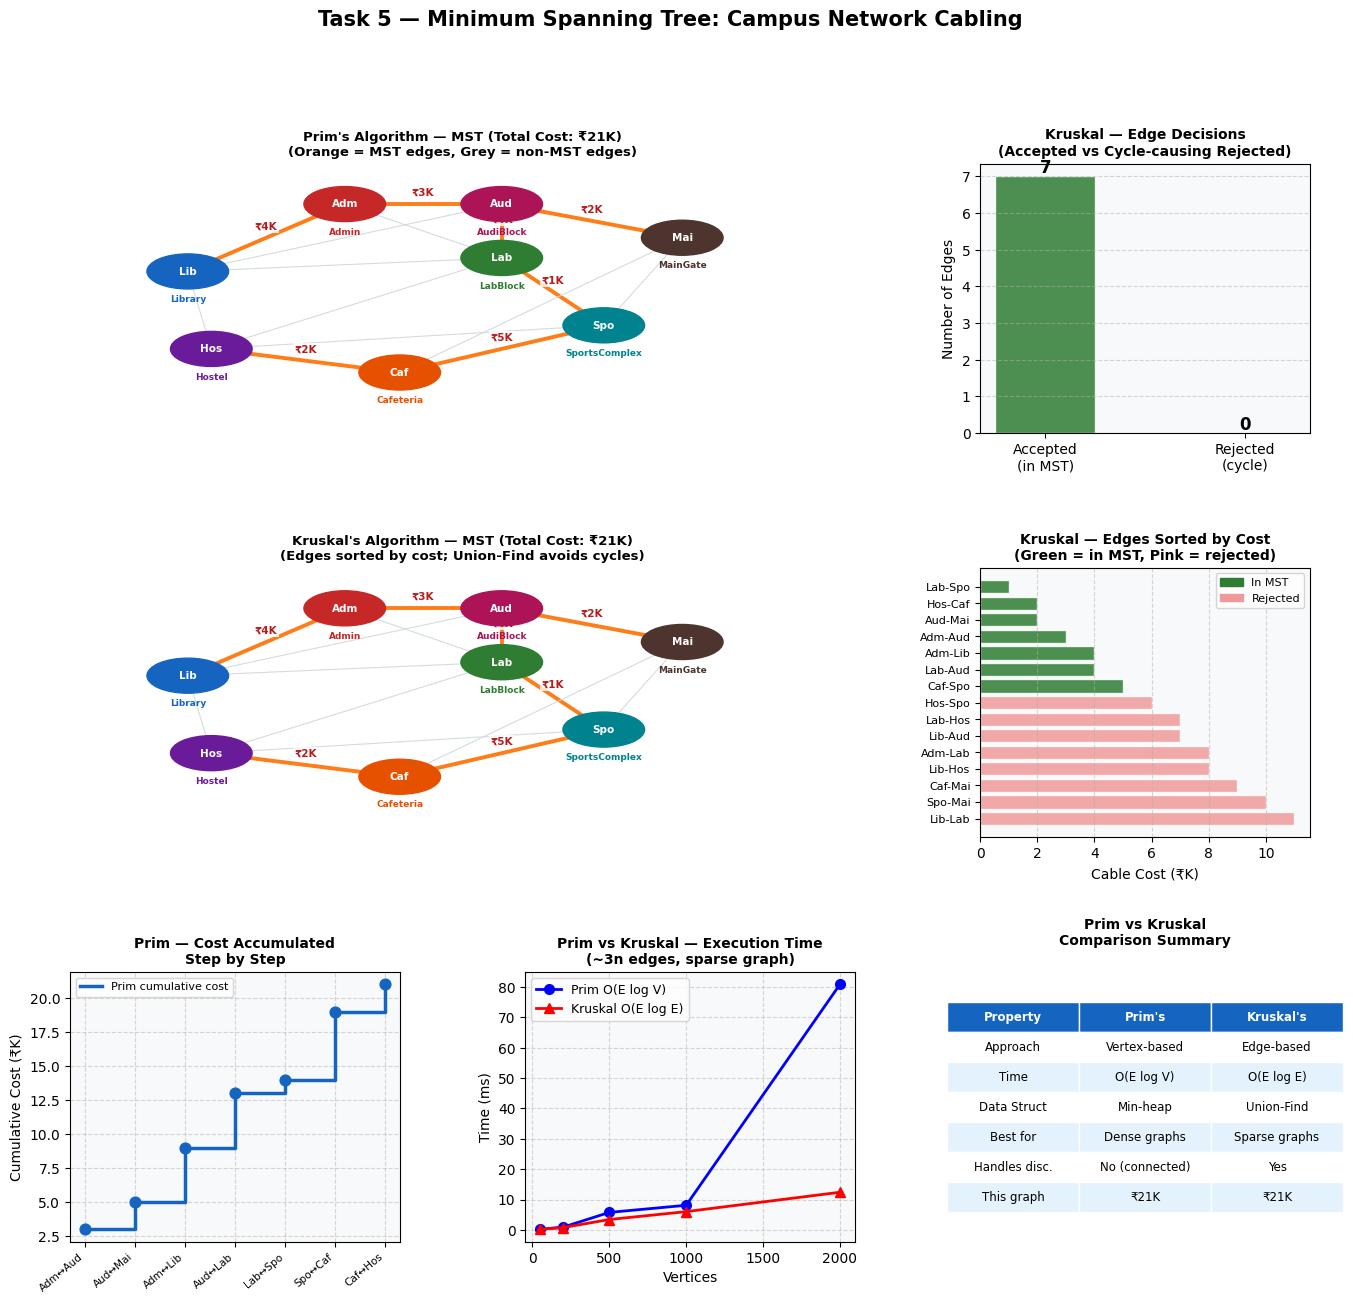


── FINAL SUMMARY ──────────────────────────────────────────────
- Prim's and Kruskal's always find the same MST cost (unique MST).
- Kruskal is preferred for sparse graphs; Prim for dense graphs.
- Prim uses a min-heap and grows from one vertex — like BFS.
- Kruskal sorts all edges and avoids cycles with Union-Find.
- MST algorithms are used in real-world: network design, cabling,
  pipeline routing, cluster analysis, and VLSI circuit design.
───────────────────────────────────────────────────────────────



In [23]:
# ============================================================
# TASK 5: MINIMUM SPANNING TREE (MST) ALGORITHMS
# Covers:
#   5A. Prim's Algorithm    — O(E log V) with priority queue
#   5B. Kruskal's Algorithm — O(E log E) with Union-Find
#   5C. Real-world: Cost-efficient network cabling between buildings
#   5D. Comparison: Prim vs Kruskal — cost, timing, structure
# ============================================================

import heapq
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

# ──────────────────────────────────────────────────────────────
# GRAPH — Campus Network Cabling Problem
# Nodes = Buildings, Edges = possible cable routes (cost in ₹1000s)
# Goal: Connect ALL buildings with MINIMUM total cable cost.
# ──────────────────────────────────────────────────────────────
BUILDINGS = ['Admin', 'Library', 'LabBlock', 'Hostel',
             'Cafeteria', 'SportsComplex', 'AudiBlock', 'MainGate']
N_B = len(BUILDINGS)
bld_idx = {b: i for i, b in enumerate(BUILDINGS)}

# Undirected weighted edges (cable cost in ₹ thousands)
CABLE_EDGES = [
    (0, 1,  4),  (0, 2,  8),  (1, 2, 11),  (1, 3,  8),
    (2, 3,  7),  (2, 5,  1),  (3, 4,  2),  (3, 5,  6),
    (4, 5,  5),  (0, 6,  3),  (6, 7,  2),  (4, 7,  9),
    (5, 7, 10),  (1, 6,  7),  (2, 6,  4),
]


# ──────────────────────────────────────────────────────────────
# 5A. PRIM'S ALGORITHM  –  O(E log V)
# Grows MST from an arbitrary start node one edge at a time.
# At each step, add the cheapest edge connecting the MST to a new node.
# Greedy strategy using a min-heap.
# Best for: Dense graphs, when edges >> vertices.
# ──────────────────────────────────────────────────────────────
def prim_mst(num_v, edges, start=0):
    """
    Prim's MST algorithm using a min-heap priority queue.
    Returns:
      - mst_edges : list of (u, v, weight) in MST
      - total_cost: total MST weight
      - steps     : list of (step, u, v, w) for visualisation
    """
    # Build undirected adjacency list
    adj = defaultdict(list)
    for u, v, w in edges:
        adj[u].append((w, v))
        adj[v].append((w, u))

    in_mst = [False] * num_v
    min_heap = [(0, start, -1)]         # (weight, node, parent)
    mst_edges  = []
    total_cost = 0
    steps      = []

    while min_heap and len(mst_edges) < num_v - 1:
        weight, u, parent = heapq.heappop(min_heap)
        if in_mst[u]:
            continue                     # Already in MST, skip

        in_mst[u] = True
        if parent != -1:
            mst_edges.append((parent, u, weight))
            total_cost += weight
            steps.append((len(mst_edges), parent, u, weight))

        for edge_w, v in adj[u]:
            if not in_mst[v]:
                heapq.heappush(min_heap, (edge_w, v, u))

    return mst_edges, total_cost, steps


prim_edges, prim_cost, prim_steps = prim_mst(N_B, CABLE_EDGES, start=0)

print("═" * 65)
print("5A. PRIM'S ALGORITHM — Campus Network Cabling")
print("═" * 65)
print(f"Starting from: {BUILDINGS[0]}")
print(f"\n{'Step':<6} {'Edge':<35} {'Cost (₹K)'}")
print("─" * 55)
for step, u, v, w in prim_steps:
    print(f"  {step:<4}  {BUILDINGS[u]:<16} ↔ {BUILDINGS[v]:<16}  {w:>5}")
print(f"\n  Total MST Cost: ₹{prim_cost},000")
print(f"  Edges in MST: {len(prim_edges)} (connects all {N_B} buildings)")


# ──────────────────────────────────────────────────────────────
# 5B. KRUSKAL'S ALGORITHM  –  O(E log E)
# Sorts ALL edges by weight, then greedily adds the cheapest
# edge that does NOT form a cycle (using Union-Find / DSU).
# Best for: Sparse graphs, when edges << vertices².
# ──────────────────────────────────────────────────────────────
class UnionFind:
    """
    Disjoint Set Union (DSU) / Union-Find data structure.
    Supports union by rank and path compression.
    find: O(α(n)) ≈ O(1)   union: O(α(n)) ≈ O(1)
    """
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank   = [0] * n

    def find(self, x):
        """Find root with PATH COMPRESSION — flattens tree."""
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])   # Path compress
        return self.parent[x]

    def union(self, x, y):
        """Union by RANK — attach smaller tree under larger."""
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False                 # Already in same set → cycle!
        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx
        self.parent[ry] = rx
        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1
        return True


def kruskal_mst(num_v, edges):
    """
    Kruskal's MST algorithm.
    Returns:
      - mst_edges : list of (u, v, weight) in MST
      - total_cost: total MST weight
      - steps     : list of (step, u, v, w, accepted) for visualisation
    """
    sorted_edges = sorted(edges, key=lambda x: x[2])    # Sort by weight
    dsu = UnionFind(num_v)
    mst_edges  = []
    total_cost = 0
    steps      = []

    for u, v, w in sorted_edges:
        accepted = dsu.union(u, v)      # Add edge if no cycle
        steps.append((u, v, w, accepted))
        if accepted:
            mst_edges.append((u, v, w))
            total_cost += w
            if len(mst_edges) == num_v - 1:
                break                   # MST complete

    return mst_edges, total_cost, steps


kruskal_edges, kruskal_cost, kruskal_steps = kruskal_mst(N_B, CABLE_EDGES)

print("\n" + "═" * 65)
print("5B. KRUSKAL'S ALGORITHM — Campus Network Cabling")
print("═" * 65)
print(f"{'Edge (sorted by cost)':<40} {'Cost':>6} {'Decision'}")
print("─" * 58)
for u, v, w, accepted in kruskal_steps:
    decision = "✓ ADDED to MST" if accepted else "✗ SKIPPED (cycle)"
    print(f"  {BUILDINGS[u]:<18} ↔ {BUILDINGS[v]:<18} {w:>4}   {decision}")

print(f"\n  Total MST Cost: ₹{kruskal_cost},000")
print(f"  Prim and Kruskal agree: {prim_cost == kruskal_cost}")
print(f"  MST is unique (costs match): {'Yes' if prim_cost == kruskal_cost else 'Possibly different'}")


# ──────────────────────────────────────────────────────────────
# 5C. TIMING COMPARISON: Prim vs Kruskal
# ──────────────────────────────────────────────────────────────
def random_undirected_graph(num_v, num_e):
    """Generate random undirected weighted graph."""
    edges = []
    added = set()
    while len(edges) < num_e:
        u = random.randint(0, num_v - 1)
        v = random.randint(0, num_v - 1)
        if u != v and (u,v) not in added and (v,u) not in added:
            w = random.randint(1, 100)
            edges.append((u, v, w))
            added.add((u, v))
    return edges

sizes_mst = [50, 200, 500, 1000, 2000]
TRIALS    = 5
prim_times, kruskal_times = [], []

print("\nTiming MST Algorithms:")
for n in sizes_mst:
    e = n * 3
    edges_rand = random_undirected_graph(n, e)
    pt, kt = [], []
    for _ in range(TRIALS):
        t0 = time.perf_counter(); prim_mst(n, edges_rand, 0);    pt.append(time.perf_counter()-t0)
        t0 = time.perf_counter(); kruskal_mst(n, edges_rand);    kt.append(time.perf_counter()-t0)
    prim_times.append(np.mean(pt)*1000)
    kruskal_times.append(np.mean(kt)*1000)
    print(f"  n={n:>5} (E={e:>6}) | Prim: {prim_times[-1]:.3f}ms  Kruskal: {kruskal_times[-1]:.3f}ms")


# ──────────────────────────────────────────────────────────────
# PLOTTING
# ──────────────────────────────────────────────────────────────
BLD_POS = {
    'Admin':         (0.35, 0.88),
    'Library':       (0.15, 0.68),
    'LabBlock':      (0.55, 0.72),
    'Hostel':        (0.18, 0.45),
    'Cafeteria':     (0.42, 0.38),
    'SportsComplex': (0.68, 0.52),
    'AudiBlock':     (0.55, 0.88),
    'MainGate':      (0.78, 0.78),
}
BLD_COLORS = ['#C62828','#1565C0','#2E7D32','#6A1B9A',
              '#E65100','#00838F','#AD1457','#4E342E']

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Task 5 — Minimum Spanning Tree: Campus Network Cabling",
             fontsize=15, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

def draw_mst_graph(ax, all_edges, mst_edge_set, title, positions, building_names, colors):
    """Draw graph with MST edges highlighted."""
    ax.set_xlim(0, 1); ax.set_ylim(0.2, 1.0)
    ax.set_facecolor('#F5F5F5'); ax.axis('off')
    ax.set_title(title, fontsize=9.5, fontweight='bold')

    # All edges (thin grey)
    for u, v, w in all_edges:
        x0,y0 = list(positions.values())[u]
        x1,y1 = list(positions.values())[v]
        is_mst = (u,v) in mst_edge_set or (v,u) in mst_edge_set
        color = '#FF6F00' if is_mst else '#CFD8DC'
        lw    = 2.8       if is_mst else 0.8
        ax.plot([x0,x1],[y0,y1], color=color, lw=lw, zorder=1, alpha=0.9)
        if is_mst:
            mx, my = (x0+x1)/2, (y0+y1)/2
            ax.text(mx, my+0.025, f"₹{w}K", fontsize=7.5, color='#B71C1C',
                    ha='center', fontweight='bold',
                    bbox=dict(fc='white', ec='none', alpha=0.8, pad=1))

    # Nodes
    for i, (name, (x, y)) in enumerate(positions.items()):
        circle = plt.Circle((x, y), 0.052, color=colors[i], zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, name[:3], ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold', zorder=4)
        ax.text(x, y - 0.09, name, ha='center', fontsize=6.5,
                color=colors[i], fontweight='bold')


prim_mst_set    = {(u,v) for u,v,_ in prim_edges}
kruskal_mst_set = {(u,v) for u,v,_ in kruskal_edges}

# ── Plot A: Prim's MST ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
draw_mst_graph(ax1, CABLE_EDGES, prim_mst_set,
               f"Prim's Algorithm — MST (Total Cost: ₹{prim_cost}K)\n"
               f"(Orange = MST edges, Grey = non-MST edges)",
               BLD_POS, BUILDINGS, BLD_COLORS)

# ── Plot B: Kruskal step acceptance ──────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
accepted = [(u,v,w) for u,v,w,a in kruskal_steps if a]
rejected = [(u,v,w) for u,v,w,a in kruskal_steps if not a]
ax2.bar(['Accepted\n(in MST)', 'Rejected\n(cycle)'],
        [len(accepted), len(rejected)],
        color=['#2E7D32', '#C62828'], alpha=0.85, edgecolor='white', width=0.5)
for i, (label, val) in enumerate(zip(['Accepted', 'Rejected'], [len(accepted), len(rejected)])):
    ax2.text(i, val + 0.1, str(val), ha='center', fontsize=12, fontweight='bold')
ax2.set_title("Kruskal — Edge Decisions\n(Accepted vs Cycle-causing Rejected)",
              fontsize=10, fontweight='bold')
ax2.set_ylabel("Number of Edges"); ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.set_facecolor('#f8f9fa')

# ── Plot C: Kruskal's MST ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
draw_mst_graph(ax3, CABLE_EDGES, kruskal_mst_set,
               f"Kruskal's Algorithm — MST (Total Cost: ₹{kruskal_cost}K)\n"
               f"(Edges sorted by cost; Union-Find avoids cycles)",
               BLD_POS, BUILDINGS, BLD_COLORS)

# ── Plot D: Edge cost sorted waterfall ───────────────────────
ax4 = fig.add_subplot(gs[1, 2])
sorted_all = sorted(CABLE_EDGES, key=lambda x: x[2])
edge_labels = [f"{BUILDINGS[u][:3]}-{BUILDINGS[v][:3]}" for u,v,w in sorted_all]
edge_costs  = [w for u,v,w in sorted_all]
edge_colors = ['#2E7D32' if (u,v) in kruskal_mst_set or (v,u) in kruskal_mst_set
               else '#EF9A9A' for u,v,w in sorted_all]
bars = ax4.barh(range(len(sorted_all)), edge_costs, color=edge_colors, alpha=0.85, edgecolor='white')
ax4.set_yticks(range(len(sorted_all)))
ax4.set_yticklabels(edge_labels, fontsize=8)
ax4.set_xlabel("Cable Cost (₹K)")
ax4.set_title("Kruskal — Edges Sorted by Cost\n(Green = in MST, Pink = rejected)",
              fontsize=10, fontweight='bold')
ax4.grid(axis='x', linestyle='--', alpha=0.5); ax4.set_facecolor('#f8f9fa')
ax4.invert_yaxis()
import matplotlib.patches as mpatches
ax4.legend(handles=[mpatches.Patch(color='#2E7D32', label='In MST'),
                    mpatches.Patch(color='#EF9A9A', label='Rejected')], fontsize=8)

# ── Plot E: Prim step-by-step cost accumulation ──────────────
ax5 = fig.add_subplot(gs[2, 0])
cumulative_prim = np.cumsum([w for _,_,w in prim_edges])
prim_edge_labels = [f"{BUILDINGS[u][:3]}↔{BUILDINGS[v][:3]}" for u,v,_ in prim_edges]
ax5.step(range(1, len(cumulative_prim)+1), cumulative_prim, where='post',
         color='#1565C0', lw=2.5, label="Prim cumulative cost")
ax5.scatter(range(1, len(cumulative_prim)+1), cumulative_prim,
            color='#1565C0', s=60, zorder=5)
ax5.set_xticks(range(1, len(prim_edges)+1))
ax5.set_xticklabels(prim_edge_labels, rotation=40, ha='right', fontsize=7.5)
ax5.set_ylabel("Cumulative Cost (₹K)")
ax5.set_title("Prim — Cost Accumulated\nStep by Step", fontsize=10, fontweight='bold')
ax5.grid(True, linestyle='--', alpha=0.5); ax5.set_facecolor('#f8f9fa')
ax5.legend(fontsize=8)

# ── Plot F: Prim vs Kruskal timing ──────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(sizes_mst, prim_times,    'bo-', lw=2, ms=7, label="Prim O(E log V)")
ax6.plot(sizes_mst, kruskal_times, 'r^-', lw=2, ms=7, label="Kruskal O(E log E)")
ax6.set_xlabel("Vertices"); ax6.set_ylabel("Time (ms)")
ax6.set_title("Prim vs Kruskal — Execution Time\n(~3n edges, sparse graph)",
              fontsize=10, fontweight='bold')
ax6.legend(fontsize=9); ax6.grid(True, linestyle='--', alpha=0.5)
ax6.set_facecolor('#f8f9fa')

# ── Plot G: Algorithm summary comparison table ────────────────
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
table_data = [
    ['Property', "Prim's", "Kruskal's"],
    ['Approach',     'Vertex-based',  'Edge-based'],
    ['Time',         'O(E log V)',     'O(E log E)'],
    ['Data Struct',  'Min-heap',       'Union-Find'],
    ['Best for',     'Dense graphs',   'Sparse graphs'],
    ['Handles disc.','No (connected)', 'Yes'],
    [f'This graph',  f'₹{prim_cost}K',f'₹{kruskal_cost}K'],
]
tbl = ax7.table(cellText=table_data[1:], colLabels=table_data[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
tbl.scale(1.2, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('white')
ax7.set_title("Prim vs Kruskal\nComparison Summary", fontsize=10, fontweight='bold', pad=20)

plt.show()

print("""
── FINAL SUMMARY ──────────────────────────────────────────────
- Prim's and Kruskal's always find the same MST cost (unique MST).
- Kruskal is preferred for sparse graphs; Prim for dense graphs.
- Prim uses a min-heap and grows from one vertex — like BFS.
- Kruskal sorts all edges and avoids cycles with Union-Find.
- MST algorithms are used in real-world: network design, cabling,
  pipeline routing, cluster analysis, and VLSI circuit design.
───────────────────────────────────────────────────────────────
""")